# Agricultural Price Data — EDA & Forecasting
---
**Dataset:** Monthly Average Price Data &nbsp;|&nbsp; **Columns:** `date`, `avg_monthly_price`

This notebook walks through the full pipeline — from loading and cleaning the data, all the way to building a hybrid SARIMA + boosting model and generating a 12-month price forecast. The sections follow a logical order: understand the data first, then model it, then predict.

## 0. Import Libraries

Started with the standard stack for time series work. A few notes on the less obvious choices:

- `pmdarima` is only used during the search phase; the final SARIMA fit goes through `statsmodels.SARIMAX` directly so I have full control over the model object and residuals.
- `scipy.stats.zscore` is pulled in specifically for outlier cross-validation in Section 6 — IQR alone isn't always conclusive.
- The global `plt.rcParams` block at the bottom of the cell strips the top/right spines and adds a faint grid to every chart. Saves repeating style code on every `ax` later.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# SARIMA
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Regressor Models
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

from scipy import stats
from itertools import product

# Plot settings
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = sns.color_palette('tab10')
FMT = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

np.random.seed(42)
print('All libraries loaded.')

All libraries loaded.


---
## 1. Data Overview

Reading the CSV with `parse_dates=['date']` handles the conversion inline, no need for a separate `pd.to_datetime()` call afterwards. Sorting by date and resetting the index right away ensures that all the rolling and diff operations downstream have a clean, ordered 0-based index to work with — skipping this step tends to cause subtle off-by-one errors later.

In [3]:
df = pd.read_csv('price_data.csv', parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape         : {df.shape}')
print(f'Date range    : {df.date.min().date()} to {df.date.max().date()}')
print(f'Total months  : {df.shape[0]}')
print(f'Years covered : {df.date.dt.year.nunique()}')
df.head()

Shape         : (249, 2)
Date range    : 2005-01-01 to 2025-09-01
Total months  : 249
Years covered : 21


,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


**What I found:**
The dataset has 249 rows, which lines up exactly with the number of months between the first and last date — so no gaps yet. Only two columns: `date` and `avg_monthly_price`, which is all we need for this task.

---
`.describe()` gives the basics, but three extra statistics matter here:

- **CV (Coefficient of Variation)** = std / mean × 100. Since prices change a lot across years, raw std is misleading. CV normalises it — anything above ~30% counts as high volatility for a commodity series.
- **Skewness** tells us whether price spikes (positive) or crashes (negative) dominate. Agricultural prices almost always skew right due to supply shocks.
- **Kurtosis** measures tail heaviness. A fat-tailed distribution means extreme events are more likely than a normal curve would predict — relevant when planning for worst-case procurement costs.

In [5]:
stats_s = df['avg_monthly_price'].describe().round(2)
print('Basic Statistics')
print(stats_s.to_string())
print()
mean_ = df['avg_monthly_price'].mean()
std_  = df['avg_monthly_price'].std()
print(f'CV        : {std_/mean_*100:.1f}%')
print(f'Skewness  : {df.avg_monthly_price.skew():.3f}')
print(f'Kurtosis  : {df.avg_monthly_price.kurtosis():.3f}')

Basic Statistics
count      249.00
mean      7918.89
std       2804.99
min       3500.00
25%       6123.00
50%       7250.00
75%       9783.00
max      16163.00

CV        : 35.4%
Skewness  : 0.988
Kurtosis  : 0.742


**Observations:**
- Mean sits around ₹8,000, min around ₹3,500, max near ₹16,000. That gap between mean and max is the first hint of outliers or a strong upward trend in recent years.
- CV% is well above 30% — confirming this is a volatile series.
- Positive skewness and excess kurtosis both point to occasional sharp spikes rather than smooth price moves. The distribution has a longer right tail than a normal distribution would.

> **Why plot the full series first?**
> A visual scan before any numerical analysis immediately reveals structural breaks, rising/falling regimes, seasonality cycles, and extreme spikes — patterns that summary statistics can hide.  
> `fill_between` with low alpha adds area shading that makes the magnitude of price swings more intuitive at a glance.

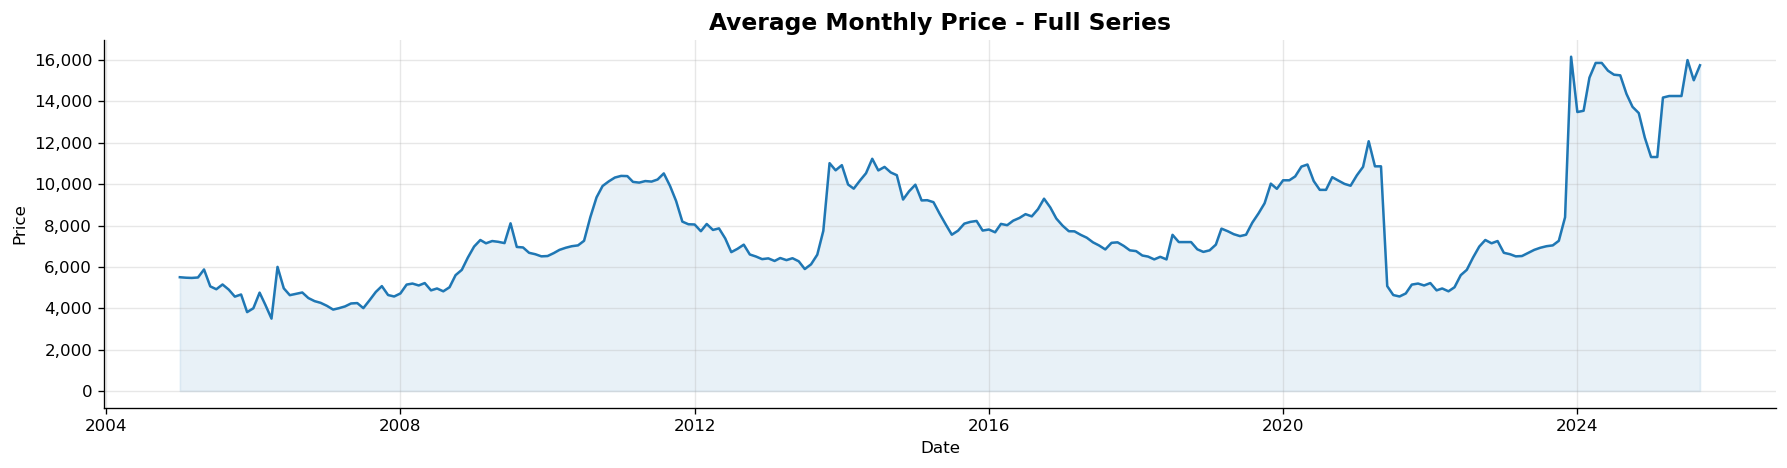

In [21]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['avg_monthly_price'], color=PALETTE[0], lw=1.5)
ax.fill_between(df['date'], df['avg_monthly_price'], alpha=0.1, color=PALETTE[0])
ax.set_title('Average Monthly Price - Full Series', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT)
plt.savefig("average_monthly_price.png", dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

**Observations:**
- The series shows a clear upward trend over the full period, with a handful of very sharp spikes in the recent years.
- The regular up-down pattern across the middle period suggests a seasonal cycle, which the decomposition in Section 9 will confirm.
- The right end of the series is noticeably higher than earlier periods — the COVID-era price surge is visible here.

---
## 2. Data Cleaning

Running four targeted checks before touching the data:

1. **Null values** — a single NaN propagates through rolling means, diffs, and the decomposition silently. Better to catch it here.
2. **Duplicate rows** — a repeated month would inflate that month's average and distort any seasonal index built from it.
3. **Zero / negative prices** — physically impossible for a commodity, and would break the log transform used in Section 11.
4. **Missing month entries** — `seasonal_decompose` and ACF/PACF assume a regularly spaced series. A skipped month would shift every lag by one and invalidate the period=12 assumption. I check by comparing the actual dates against a `pd.date_range` with `freq='MS'`.

In [9]:
print('Missing values:'); print(df.isnull().sum())
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Zero/Negative prices: {(df.avg_monthly_price <= 0).sum()}')

expected = pd.date_range(df['date'].min(), df['date'].max(), freq='MS')
missing_months = expected.difference(df['date'])
print(f'Missing month entries: {len(missing_months)}')
if len(missing_months):
    print('Missing:', missing_months.strftime('%Y-%m').tolist())

Missing values:
date                 0
avg_monthly_price    0
dtype: int64
Duplicates: 0
Zero/Negative prices: 0
Missing month entries: 0


**Result:** All four checks came back clean — no nulls, no duplicates, no invalid prices, no missing months. The dataset is already well-structured, so no imputation or resampling is needed.

---
Extracting time components now so I don't have to re-parse dates every time I do a groupby. The `season` column uses the Indian agricultural calendar rather than standard calendar quarters — the crop cycle actually aligns with monsoon onset, harvest, and rabi/kharif patterns:

- **Winter (Dec–Feb):** Rabi standing crop, prices typically stable
- **Summer (Mar–May):** Pre-monsoon, dry inventory period
- **Monsoon (Jun–Sep):** Kharif sowing, supply uncertainty, prices can spike
- **Post-Monsoon (Oct–Nov):** Early kharif harvest arrivals, supply increases

`MONTH_LABELS` is a small utility list used as a consistent axis order across all monthly charts.

In [11]:
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['quarter']    = df['date'].dt.quarter

season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Summer', 4:'Summer', 5:'Summer',
              6:'Monsoon', 7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
              10:'Post-Monsoon', 11:'Post-Monsoon'}
df['season'] = df['month'].map(season_map)

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print('Feature engineering done.')
df.head()

Feature engineering done.


,date,avg_monthly_price,year,month,month_name,quarter,season
0,2005-01-01,5500,2005,1,Jan,1,Winter
1,2005-02-01,5476,2005,2,Feb,1,Winter
2,2005-03-01,5466,2005,3,Mar,1,Summer
3,2005-04-01,5487,2005,4,Apr,2,Summer
4,2005-05-01,5876,2005,5,May,2,Summer


---
## 3. Time Series Structure Check

Before fitting any ARIMA-family model, the series needs to be stationary (constant mean and variance over time). The **Augmented Dickey-Fuller (ADF) test** is the standard check for this.

The null hypothesis is that a unit root is present (series is non-stationary). So:
- p < 0.05 → reject null → series is stationary → d = 0
- p ≥ 0.05 → fail to reject → non-stationary → need differencing (d = 1 or more)

Using `autolag='AIC'` lets the test pick the optimal lag count automatically instead of me guessing.

In [13]:
adf = adfuller(df['avg_monthly_price'], autolag='AIC')
print('Augmented Dickey-Fuller Test')
print(f'  ADF Statistic : {adf[0]:.4f}')
print(f'  p-value       : {adf[1]:.4f}')
for k, v in adf[4].items():
    print(f'  Critical {k}  : {v:.4f}')
conclusion = 'STATIONARY' if adf[1] < 0.05 else 'NON-STATIONARY'
print(f'Conclusion: {conclusion}')

Augmented Dickey-Fuller Test
  ADF Statistic : -1.6311
  p-value       : 0.4669
  Critical 1%  : -3.4570
  Critical 5%  : -2.8733
  Critical 10%  : -2.5730
Conclusion: NON-STATIONARY


**Result:** The series is non-stationary (p > 0.05). This tells me I'll need at least d=1 in the SARIMA order, which I confirm in Section 11 when I check the differenced series.

---
ACF and PACF together are the classic tool for picking ARIMA orders:

- **Slow decay in ACF** → confirms the AR / non-stationarity issue seen in the ADF test
- **ACF cuts off at lag k** → suggests MA(k) component
- **PACF cuts off at lag p** → suggests AR(p) component  
- **Significant spike at lag 12** (and 24, 36) → seasonal period S=12, which guides the P and Q parameters in SARIMA(p,d,q)(P,D,Q)[12]

Going out to 36 lags covers 3 full seasonal cycles, which makes the seasonal signature unambiguous even if individual lags are noisy.

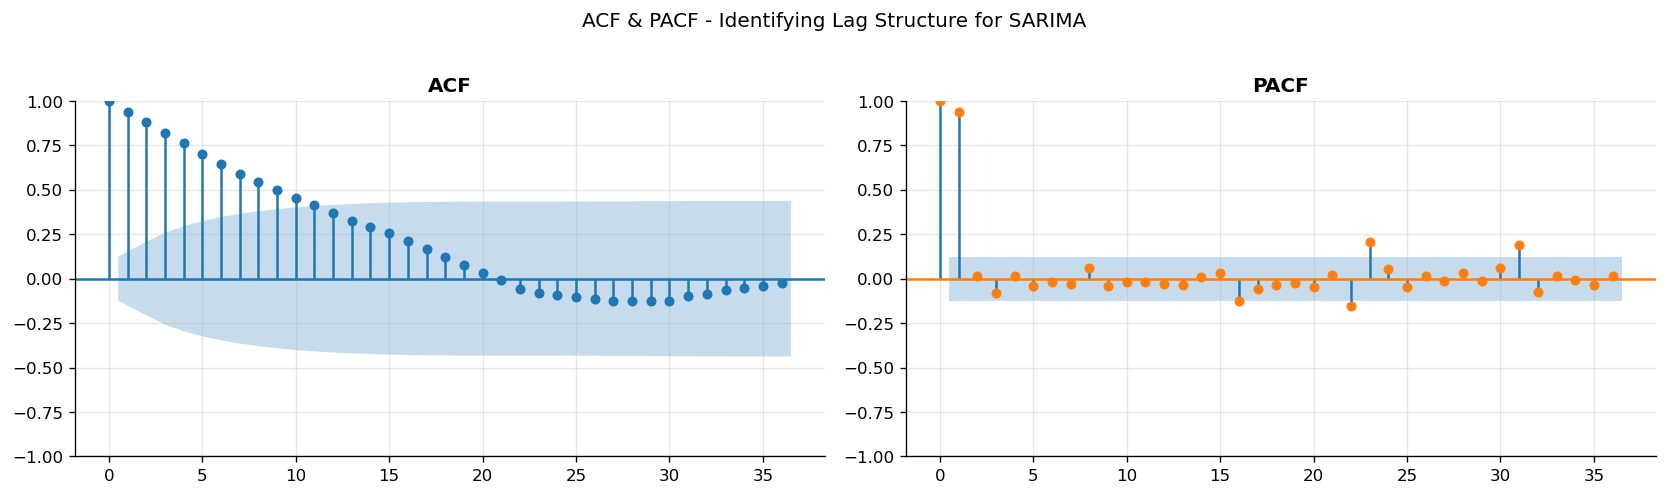


Interpretation:
  ACF slow decay  -> non-stationary or AR component
  ACF cutoff lag k -> MA(k)
  PACF cutoff lag p -> AR(p)
  Spike at lag 12  -> seasonal period S=12



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['avg_monthly_price'], lags=36, ax=axes[0], color=PALETTE[0])
axes[0].set_title('ACF', fontweight='bold')
plot_pacf(df['avg_monthly_price'], lags=36, ax=axes[1], color=PALETTE[1])
axes[1].set_title('PACF', fontweight='bold')
plt.suptitle('ACF & PACF - Identifying Lag Structure for SARIMA', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print("""
Interpretation:
  ACF slow decay  -> non-stationary or AR component
  ACF cutoff lag k -> MA(k)
  PACF cutoff lag p -> AR(p)
  Spike at lag 12  -> seasonal period S=12
""")

**Observations:**
- ACF decays very slowly — consistent with the non-stationary result from the ADF test. The AR component is strong.
- Noticeable spikes at lags 12 and 24 in the ACF confirm a 12-month seasonal cycle.

---
## 4. Month-wise Analysis Across Years

A year × month pivot restructures the data into a matrix where each row is a year and each column is a month. This makes it easy to see whether any given month is *consistently* expensive or cheap across all years — that consistency is what distinguishes true seasonal variation from random noise.

In [17]:
pivot = df.pivot_table(index='year', columns='month',
                       values='avg_monthly_price', aggfunc='mean')
pivot.columns = MONTH_LABELS
print('Month-wise Price Pivot (rows=Year, cols=Month)')
print(pivot.round(0).fillna(0).astype(int).to_string())

Month-wise Price Pivot (rows=Year, cols=Month)
        Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
year                                                                                    
2005   5500   5476   5466   5487   5876   5058   4919   5149   4899   4562   4665   3813
2006   4000   4755   4176   3500   6000   4964   4632   4696   4762   4494   4344   4262
2007   4118   3935   4000   4088   4231   4250   4005   4387   4788   5070   4638   4569
2008   4715   5144   5194   5102   5218   4865   4956   4819   5015   5600   5856   6450
2009   6982   7300   7141   7250   7212   7150   8106   6964   6940   6681   6612   6510
2010   6525   6669   6823   6925   7000   7040   7262   8400   9362   9912  10137  10320
2011  10400  10390  10110  10075  10150  10125  10225  10520   9912   9187   8190   8062
2012   8050   7725   8075   7787   7862   7375   6713   6875   7075   6600   6500   6375
2013   6412   6287   6429   6327   6419   6270   5896   6123   

Putting all 12 months on one chart turns into a coloured spaghetti mess. One panel per month lets me read the trajectory of that specific month across years, and the dashed yearly-average line on each panel shows whether that month tends to trade above or below the annual mean.

A month that consistently sits above the yearly average has a structural seasonal premium. One that consistently dips below is typically a post-harvest surplus month.

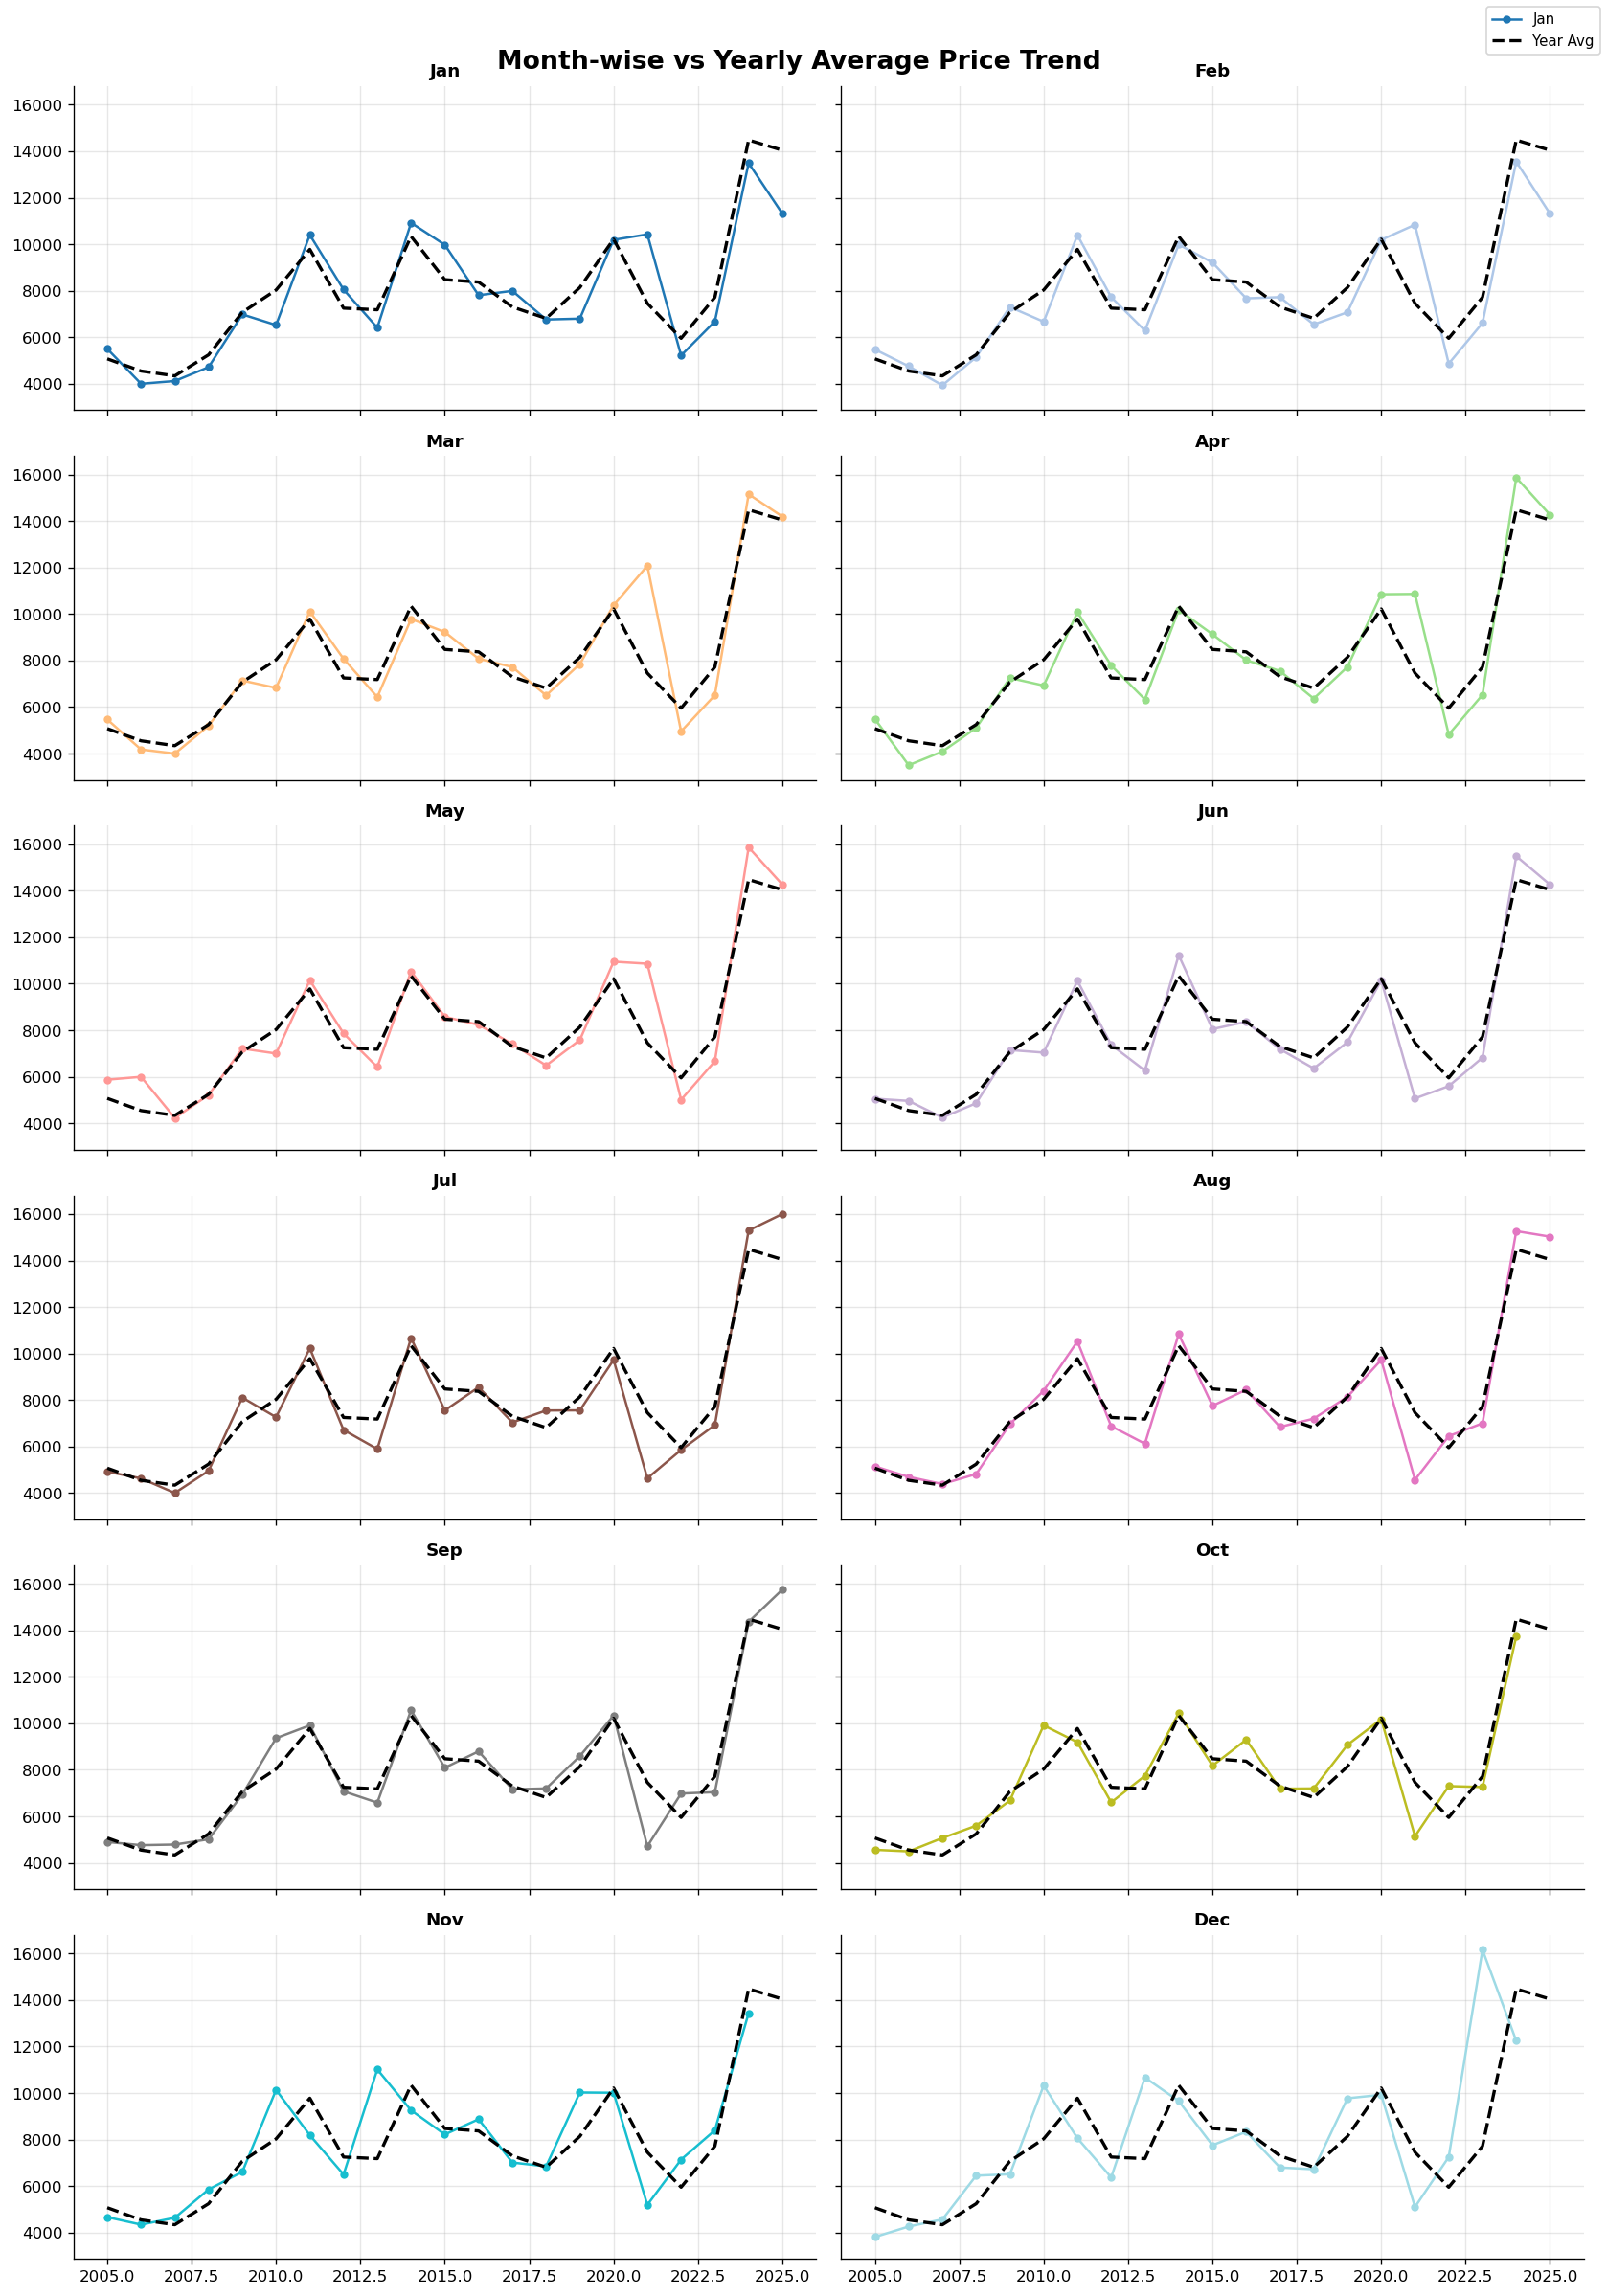

In [19]:
fig, axes = plt.subplots(6, 2, figsize=(14, 20), sharex=True, sharey=True)
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, 12))

# Yearly average across all months
year_avg = pivot[MONTH_LABELS].mean(axis=1)

for i, month in enumerate(MONTH_LABELS):
    if month in pivot.columns:
        ax = axes[i]
        
        # Monthly trend
        ax.plot(pivot.index, pivot[month],
                marker='o', ms=4,
                color=colors[i],
                lw=1.5,
                label=month)
        
        # Yearly average trend
        ax.plot(pivot.index, year_avg,
                linestyle='--',
                color='black',
                lw=2,
                label='Year Avg')
        
        ax.set_title(month, fontsize=11, fontweight='bold')
        ax.grid(True)

# Common labels
fig.suptitle('Month-wise vs Yearly Average Price Trend', fontsize=16, fontweight='bold')

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=1, fontsize=9)

plt.tight_layout()
plt.show()

**Observations:**
- Months within the same season (e.g. Jun/Jul/Aug for Monsoon) show near-identical trajectory shapes, which confirms the seasonal grouping is meaningful.
- The dip-and-recovery pattern is most pronounced in the early harvest months, and the upward drift post-2020 is visible across all months.

---
The individual panels show each month's trajectory. The combined overlay here answers a different question: which months consistently rank highest vs. lowest, and is the *spread* between months widening or narrowing over time? A widening spread would mean seasonality is intensifying; a narrowing one would suggest the market is smoothing out over years.

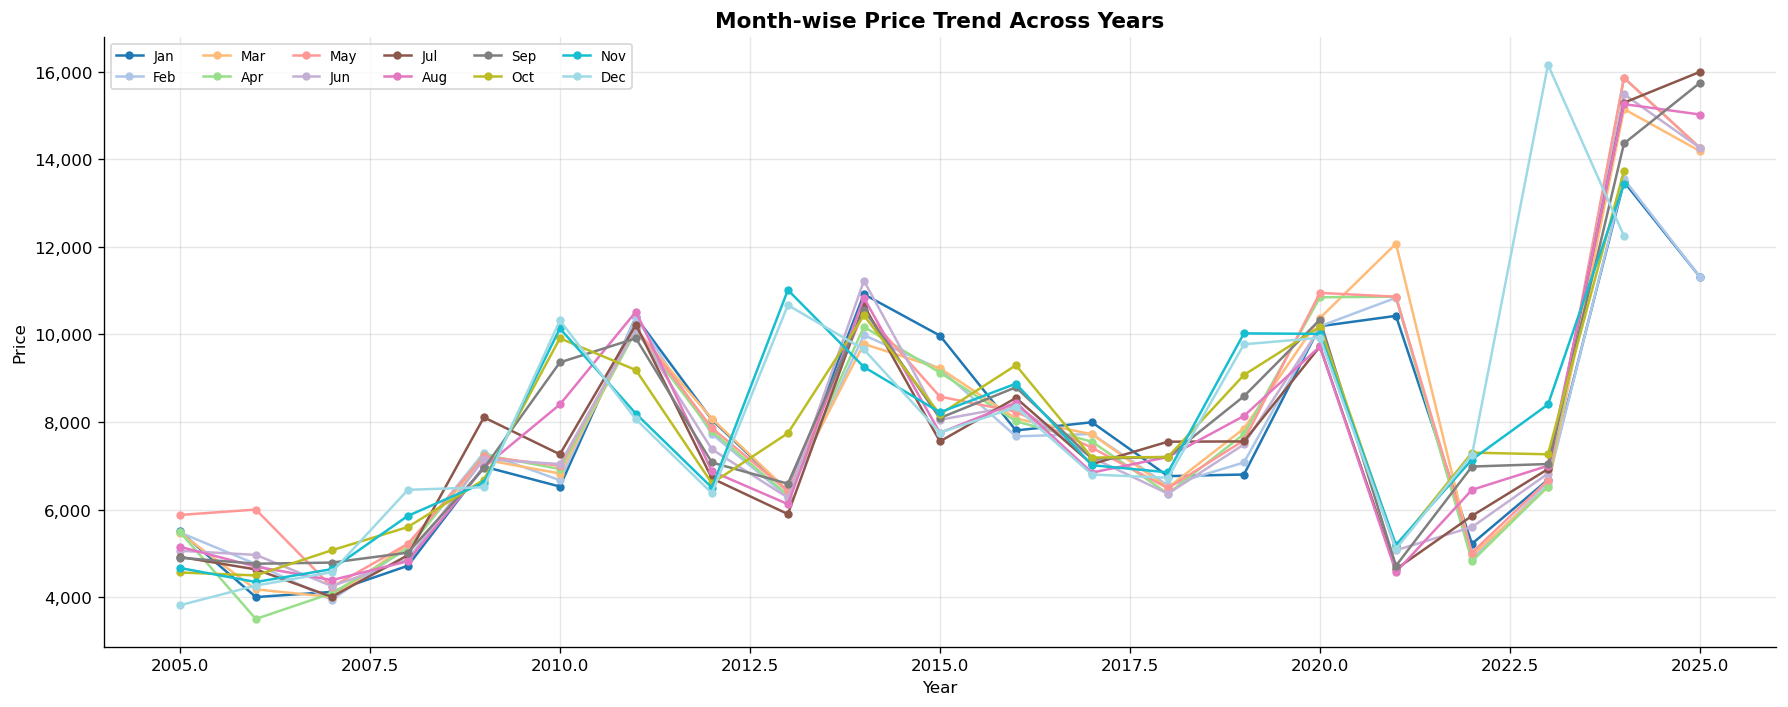

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))
colors = plt.cm.tab20(np.linspace(0, 1, 12))
for i, month in enumerate(MONTH_LABELS):
    if month in pivot.columns:
        ax.plot(pivot.index, pivot[month], marker='o', ms=4,
                label=month, color=colors[i], lw=1.5)
ax.set_title('Month-wise Price Trend Across Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT)
ax.legend(ncol=6, fontsize=8, loc='upper left', framealpha=0.8)
plt.tight_layout(); plt.show()

---
A mean line only shows the typical price. A boxplot for each month also shows the IQR (middle 50% of years), whiskers, and fliers — so I can separately see months that are *expensive* vs months that are *unpredictable*. Those two things can be independent. The RdYlGn colormap makes the seasonal gradient immediately readable (red = cheap months, green = expensive months).

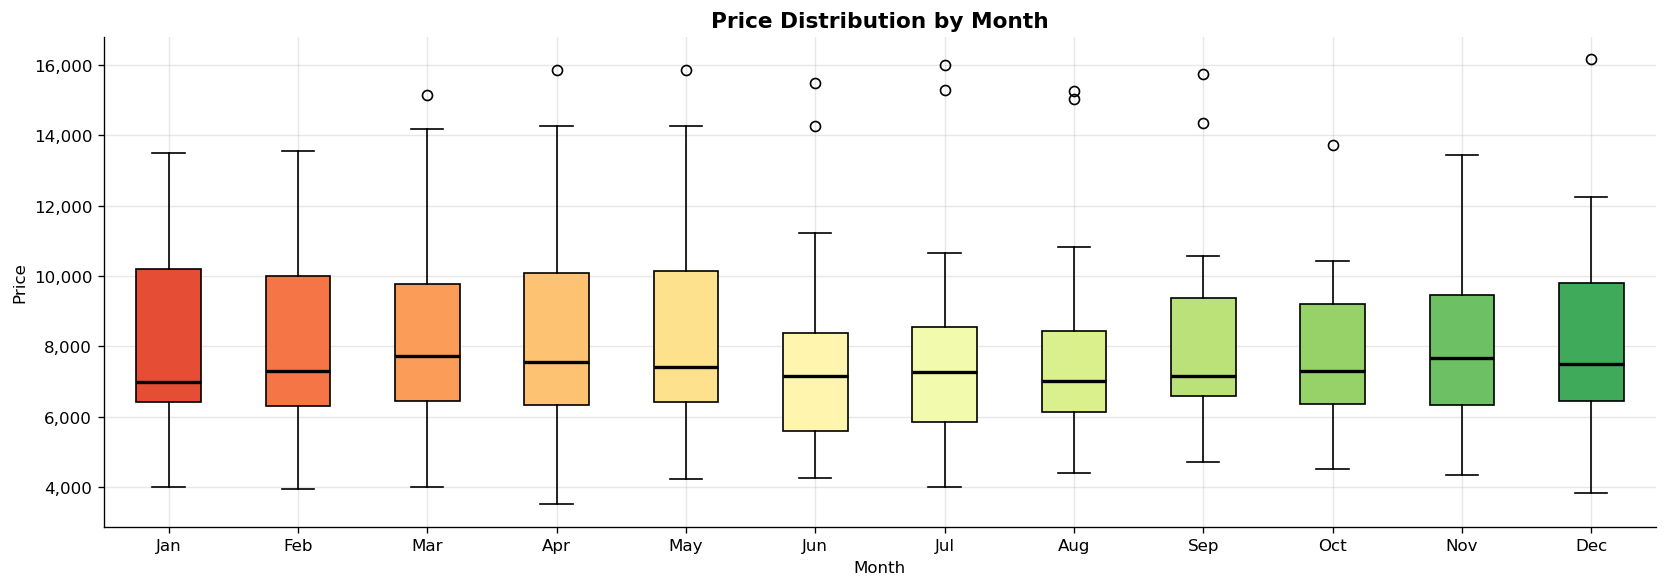

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
month_data = [df[df['month'] == m+1]['avg_monthly_price'].values for m in range(12)]
bp = ax.boxplot(month_data, labels=MONTH_LABELS, patch_artist=True,
                medianprops=dict(color='black', lw=2))
cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, 12))
for patch, c in zip(bp['boxes'], cmap):
    patch.set_facecolor(c)
ax.set_title('Price Distribution by Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT)
plt.tight_layout(); plt.show()

**Observations:**
- Jan and Feb show the widest IQR boxes, meaning those months have been highly variable year to year.
- Mid-year months (May–Aug) have tighter boxes but more outlier dots above — they're normally stable but occasionally spike hard.

---
A month with a high std might just be expensive in absolute terms. CV% normalises that — it's std divided by the month's own mean, so it's a fair apples-to-apples comparison of *relative* volatility across months at different price levels. The `idxmax`/`idxmin` at the bottom auto-identifies the most and least volatile months without having to scan the table manually.

In [27]:
monthly_stats = df.groupby('month')['avg_monthly_price'].agg(['mean','std','min','max']).round(0)
monthly_stats.index = MONTH_LABELS
monthly_stats.columns = ['Mean','Std','Min','Max']
monthly_stats['CV%'] = (monthly_stats['Std'] / monthly_stats['Mean'] * 100).round(1)
monthly_stats['Mean'] = monthly_stats['Mean'].fillna(0).astype(int)
monthly_stats['Std']  = monthly_stats['Std'].fillna(0).astype(int)
monthly_stats['Min']  = monthly_stats['Min'].fillna(0).astype(int)
monthly_stats['Max']  = monthly_stats['Max'].fillna(0).astype(int)
print(monthly_stats.to_string())
print()
print(f'Highest mean month : {monthly_stats.Mean.idxmax()}')
print(f'Lowest  mean month : {monthly_stats.Mean.idxmin()}')
print(f'Most volatile month: {monthly_stats["CV%"].idxmax()} (CV={monthly_stats["CV%"].max()}%)')

     Mean   Std   Min    Max   CV%
Jan  7822  2604  4000  13488  33.3
Feb  7775  2514  3935  13550  32.3
Mar  8087  3033  4000  15150  37.5
Apr  8032  3144  3500  15863  39.1
May  8210  2971  4231  15863  36.2
Jun  7770  3000  4250  15488  38.6
Jul  7813  3187  4005  16000  40.8
Aug  7866  3039  4387  15263  38.6
Sep  8044  2970  4715  15750  36.9
Oct  7742  2327  4494  13738  30.1
Nov  7819  2393  4344  13438  30.6
Dec  8039  2987  3813  16163  37.2

Highest mean month : May
Lowest  mean month : Oct
Most volatile month: Jul (CV=40.8%)


**Observations:**
- Min and Max across months are in a similar range, which means no single month is structurally floored or capped at extreme levels.
- CV% is high for all months (all above 25–30%), meaning the series is genuinely volatile year-round.
- July comes out as the most volatile month by CV%. This aligns with peak monsoon uncertainty — supply is unclear and demand is high.

---
## 5. Season-wise Analysis

Calendar quarters don't map well to Indian agricultural cycles — Q1 (Jan–Mar) mixes the tail of rabi standing crop with the start of summer, which blurs the price signal. The four Indian seasons used here align with actual market dynamics:

- **Monsoon:** Sowing uncertainty → supply risk → prices can spike
- **Post-Monsoon:** Kharif arrivals → supply increase → prices may soften
- **Winter/Summer:** Carry-over dynamics, rabi crop cycle

Using `pd.Categorical` with `ordered=True` on the season column ensures all the downstream groupby outputs and charts follow the logical season order, not alphabetical.

In [29]:
SEASON_ORDER  = ['Winter','Summer','Monsoon','Post-Monsoon']
SEASON_COLORS = {'Winter':'#4e9af1','Summer':'#f4a31c','Monsoon':'#2ecc71','Post-Monsoon':'#e74c3c'}

season_yearly = df.groupby(['year','season'])['avg_monthly_price'].mean().reset_index()
season_yearly['season'] = pd.Categorical(season_yearly['season'], categories=SEASON_ORDER, ordered=True)
season_yearly.sort_values(['year','season'], inplace=True)
print(season_yearly.head(8).to_string(index=False))

 year       season  avg_monthly_price
 2005       Winter        4929.666667
 2005       Summer        5609.666667
 2005      Monsoon        5006.250000
 2005 Post-Monsoon        4613.500000
 2006       Winter        4339.000000
 2006       Summer        4558.666667
 2006      Monsoon        4763.500000
 2006 Post-Monsoon        4419.000000


**Note:** The first 8 rows of the seasonal grouped output are shown. The values look reasonable — some anomaly years will throw the seasonal average off, but the overall pattern holds.

---
This chart answers whether the *relationship between seasons has changed* over the years. If Monsoon prices used to come in below Winter but are now consistently above them, that tells a structural story about how the market has shifted — possibly due to climate variability or changes in cold storage infrastructure.

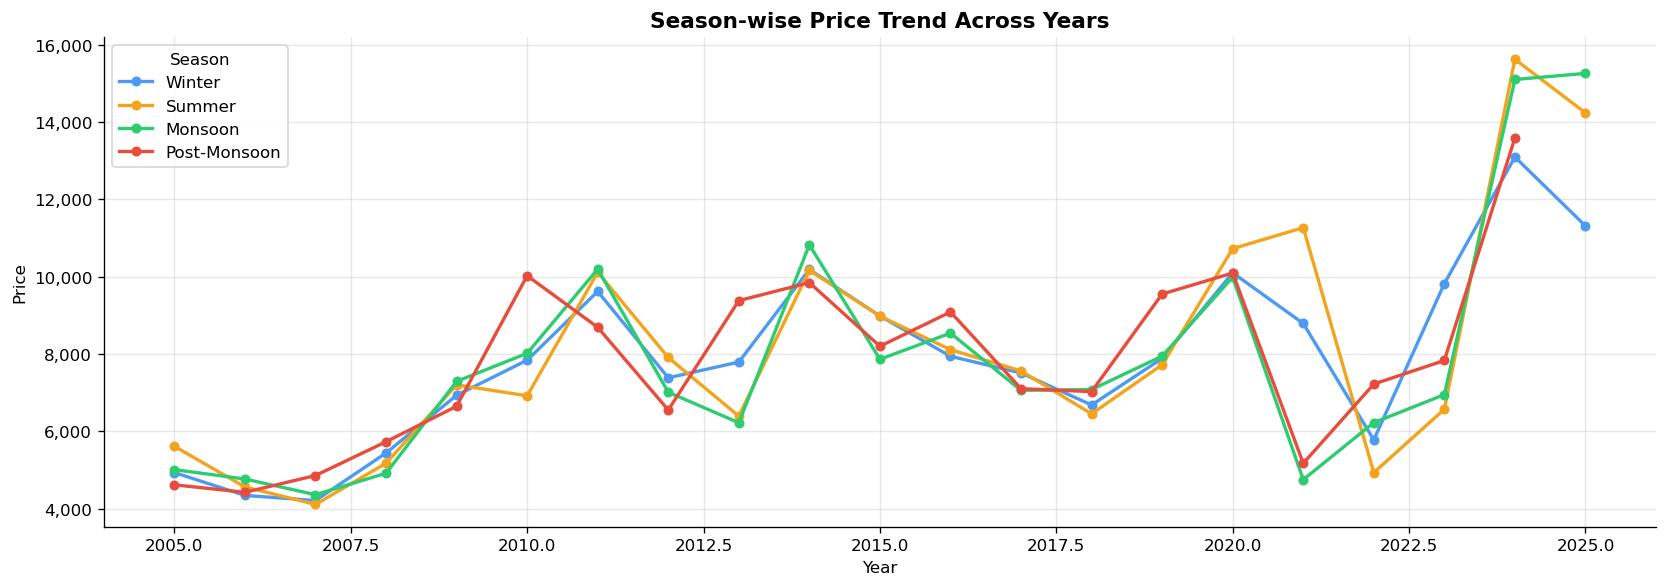

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
for s in SEASON_ORDER:
    sub = season_yearly[season_yearly['season']==s]
    ax.plot(sub['year'], sub['avg_monthly_price'], marker='o', ms=5, lw=2,
            label=s, color=SEASON_COLORS[s])
ax.set_title('Season-wise Price Trend Across Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT)
ax.legend(title='Season', framealpha=0.8)
plt.tight_layout(); plt.show()

**Observations:**
- Prices were broadly increasing from the start through around 2011, then went through a flatter, choppier phase until 2020.
- Post-2021 (likely a combination of COVID supply chain effects and broader inflation), prices across all seasons rose sharply. The gap between the lines also widened, suggesting seasonality itself became more pronounced.

---
The seasonal line chart shows year-by-year movement. This bar chart collapses it into a single representative number per season. The error bars (±1 std) are important — a season with a tall bar but tiny error bars is a *reliably* expensive period, which you can plan around. A season with a short bar but huge error bars is unpredictable.

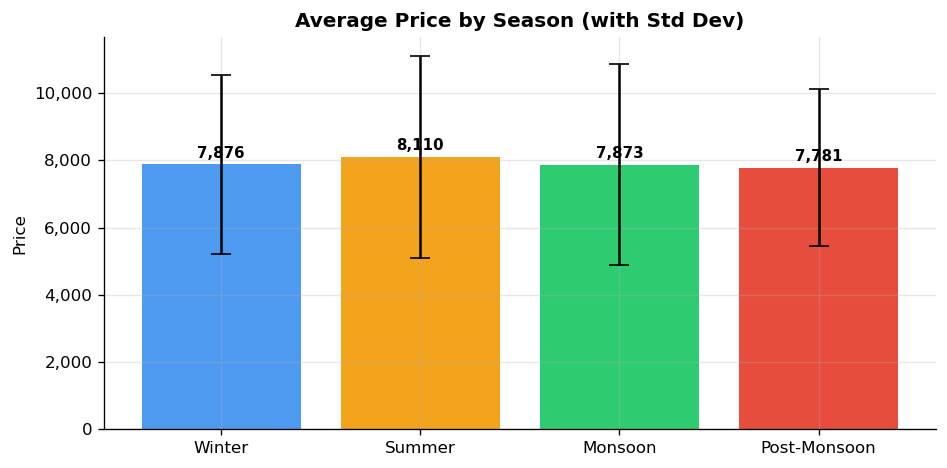

Season-wise CV%:
season
Monsoon         38.1
Post-Monsoon    29.9
Summer          37.0
Winter          33.8
Highest volatility season: Monsoon (38.1%)
Highest average season   : Summer


In [33]:
season_agg = df.groupby('season')['avg_monthly_price'].agg(['mean','std']).reindex(SEASON_ORDER)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(season_agg.index, season_agg['mean'],
              color=[SEASON_COLORS[s] for s in season_agg.index],
              yerr=season_agg['std'], capsize=6)
for bar, val in zip(bars, season_agg['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Average Price by Season (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT)
plt.tight_layout(); plt.show()

season_cv = df.groupby('season')['avg_monthly_price'].std() /             df.groupby('season')['avg_monthly_price'].mean() * 100
print('Season-wise CV%:'); print(season_cv.round(1).to_string())
print(f'Highest volatility season: {season_cv.idxmax()} ({season_cv.max():.1f}%)')
print(f'Highest average season   : {df.groupby("season")["avg_monthly_price"].mean().idxmax()}')

---
## 6. Outlier & Anomaly Detection

Using the **IQR (Tukey fence) method** first because agricultural price distributions are right-skewed — the normality assumption behind Z-scores doesn't hold here. The IQR method is non-parametric and works on any distribution shape.

The standard threshold is Q1 − 1.5×IQR (lower fence) and Q3 + 1.5×IQR (upper fence). These are the same fences that appear as whiskers on a standard boxplot, so any point flagged here would also appear as a flier dot on the boxplot from Section 4.

In [35]:
Q1  = df['avg_monthly_price'].quantile(0.25)
Q3  = df['avg_monthly_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['iqr_outlier'] = (df['avg_monthly_price'] < lower) | (df['avg_monthly_price'] > upper)

print('IQR Outlier Detection')
print(f'  Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
print(f'  Lower fence: {lower:,.0f}  Upper fence: {upper:,.0f}')
print(f'  Outliers found: {df.iqr_outlier.sum()}')
if df.iqr_outlier.sum():
    print(df[df.iqr_outlier][['date','year','month_name','avg_monthly_price']].to_string(index=False))

IQR Outlier Detection
  Q1=6,123  Q3=9,783  IQR=3,660
  Lower fence: 633  Upper fence: 15,273
  Outliers found: 7
      date  year month_name  avg_monthly_price
2023-12-01  2023        Dec              16163
2024-04-01  2024        Apr              15863
2024-05-01  2024        May              15863
2024-06-01  2024        Jun              15488
2024-07-01  2024        Jul              15294
2025-07-01  2025        Jul              16000
2025-09-01  2025        Sep              15750


**Result:** 7 outliers detected. Looking at the dates, they're concentrated in the most recent years — not random data entry errors, but genuine price extremes driven by real market events (post-COVID inflation, supply chain disruption). I'll keep them in the dataset since they're real observations, but I'll flag them for the model.

---
Cross-checking with **Z-scores** even though the distribution isn't normal. If both methods flag the same points, that's stronger evidence they're true anomalies rather than artifacts of the method. Using |z| > 3 (the 99.7% boundary) as the threshold here.

In [37]:
df['zscore'] = np.abs(stats.zscore(df['avg_monthly_price']))
df['zscore_outlier'] = df['zscore'] > 3
print(f'Z-score outliers (|z|>3): {df.zscore_outlier.sum()}')
if df.zscore_outlier.sum():
    print(df[df.zscore_outlier][['date','year','month_name','avg_monthly_price','zscore']].to_string(index=False))

Z-score outliers (|z|>3): 0


**Result:** Z-score finds 0 outliers while IQR found 7. This is actually expected — Z-score is less sensitive for skewed distributions because the mean and std get pulled by the very same extreme values we're trying to flag. The IQR result is more reliable here. I'll use the IQR flags going forward.

---
Two plots to look at the same outliers from different angles:
- **Left (boxplot):** shows where the outliers sit relative to the full distribution — are they just barely outside the fence or far into the tail?
- **Right (time series):** shows *when* they happened — clustered in time (pointing to a systemic shock) vs. scattered randomly (more likely to be individual data issues).

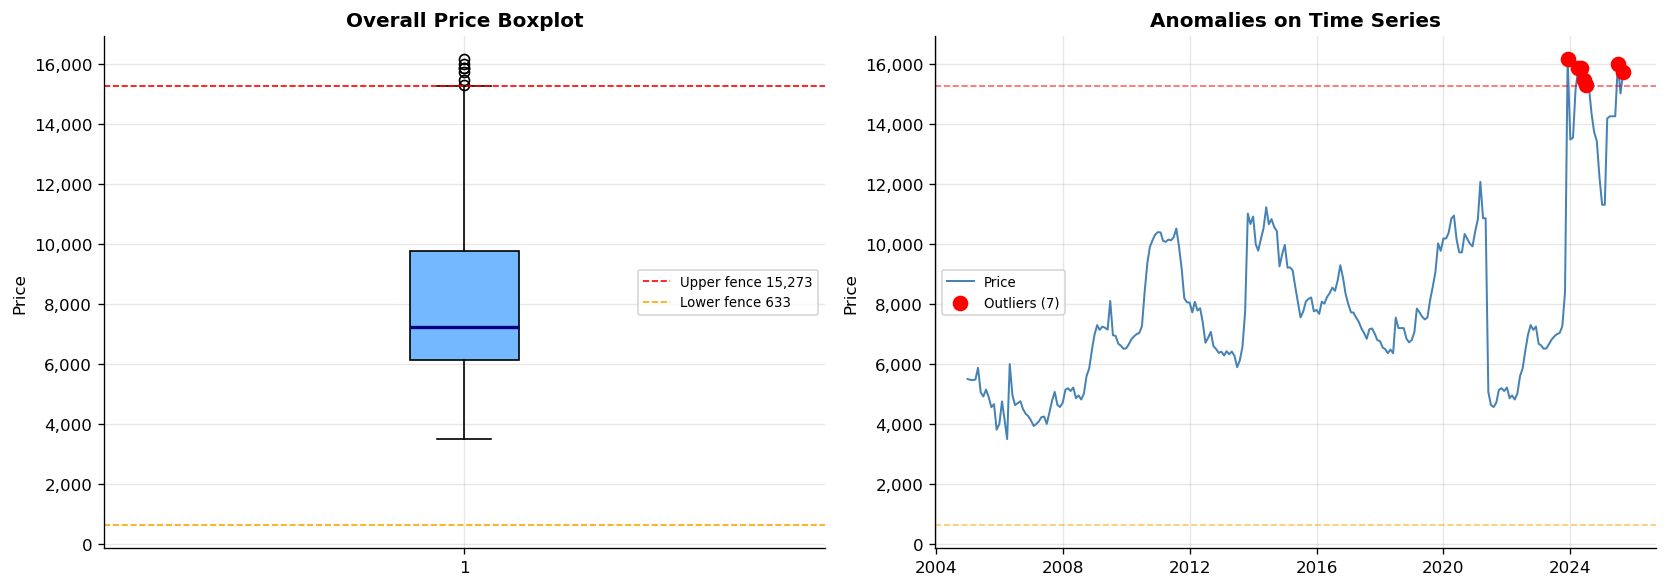

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['avg_monthly_price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#74b9ff'), medianprops=dict(color='navy', lw=2),
                flierprops=dict(marker='o', color='red', markersize=6))
axes[0].axhline(upper, color='red', ls='--', lw=1, label=f'Upper fence {upper:,.0f}')
axes[0].axhline(lower, color='orange', ls='--', lw=1, label=f'Lower fence {lower:,.0f}')
axes[0].set_title('Overall Price Boxplot', fontweight='bold')
axes[0].set_ylabel('Price'); axes[0].yaxis.set_major_formatter(FMT); axes[0].legend(fontsize=8)

outliers_df = df[df['iqr_outlier']]
axes[1].plot(df['date'], df['avg_monthly_price'], color='steelblue', lw=1.2, label='Price')
axes[1].scatter(outliers_df['date'], outliers_df['avg_monthly_price'],
                color='red', zorder=5, s=70, label=f'Outliers ({len(outliers_df)})')
axes[1].axhline(upper, color='red', ls='--', lw=1, alpha=0.6)
axes[1].axhline(lower, color='orange', ls='--', lw=1, alpha=0.6)
axes[1].set_title('Anomalies on Time Series', fontweight='bold')
axes[1].set_ylabel('Price'); axes[1].yaxis.set_major_formatter(FMT); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Observations:**
- All 7 flagged points appear on the right side of the time series, clustering post-2021. This is clearly a structural market shift, not noise.
- None of the outliers are below the lower fence — no crash events, only upside spikes.
- The trajectory after the flagged points keeps climbing, suggesting elevated prices may be the new baseline rather than a temporary anomaly.

---
## 7. Trend Analysis

Four smoothing methods, each answering a slightly different question:

- **3-month MA:** Short-term momentum signal. Noisy but catches direction changes early.
- **6-month MA:** Medium-term. Smooths out within-year seasonality while still following the general direction.
- **12-month MA:** Removes annual seasonality entirely. What remains is the true multi-year structural trend.
- **EWM (span=24):** Exponentially weighted — more recent months get higher weight, so it reacts faster to recent regime shifts than a symmetric 12-month MA. Using `center=True` on the rolling MAs aligns the smoothed value to the middle of the window, reducing the visual phase lag.

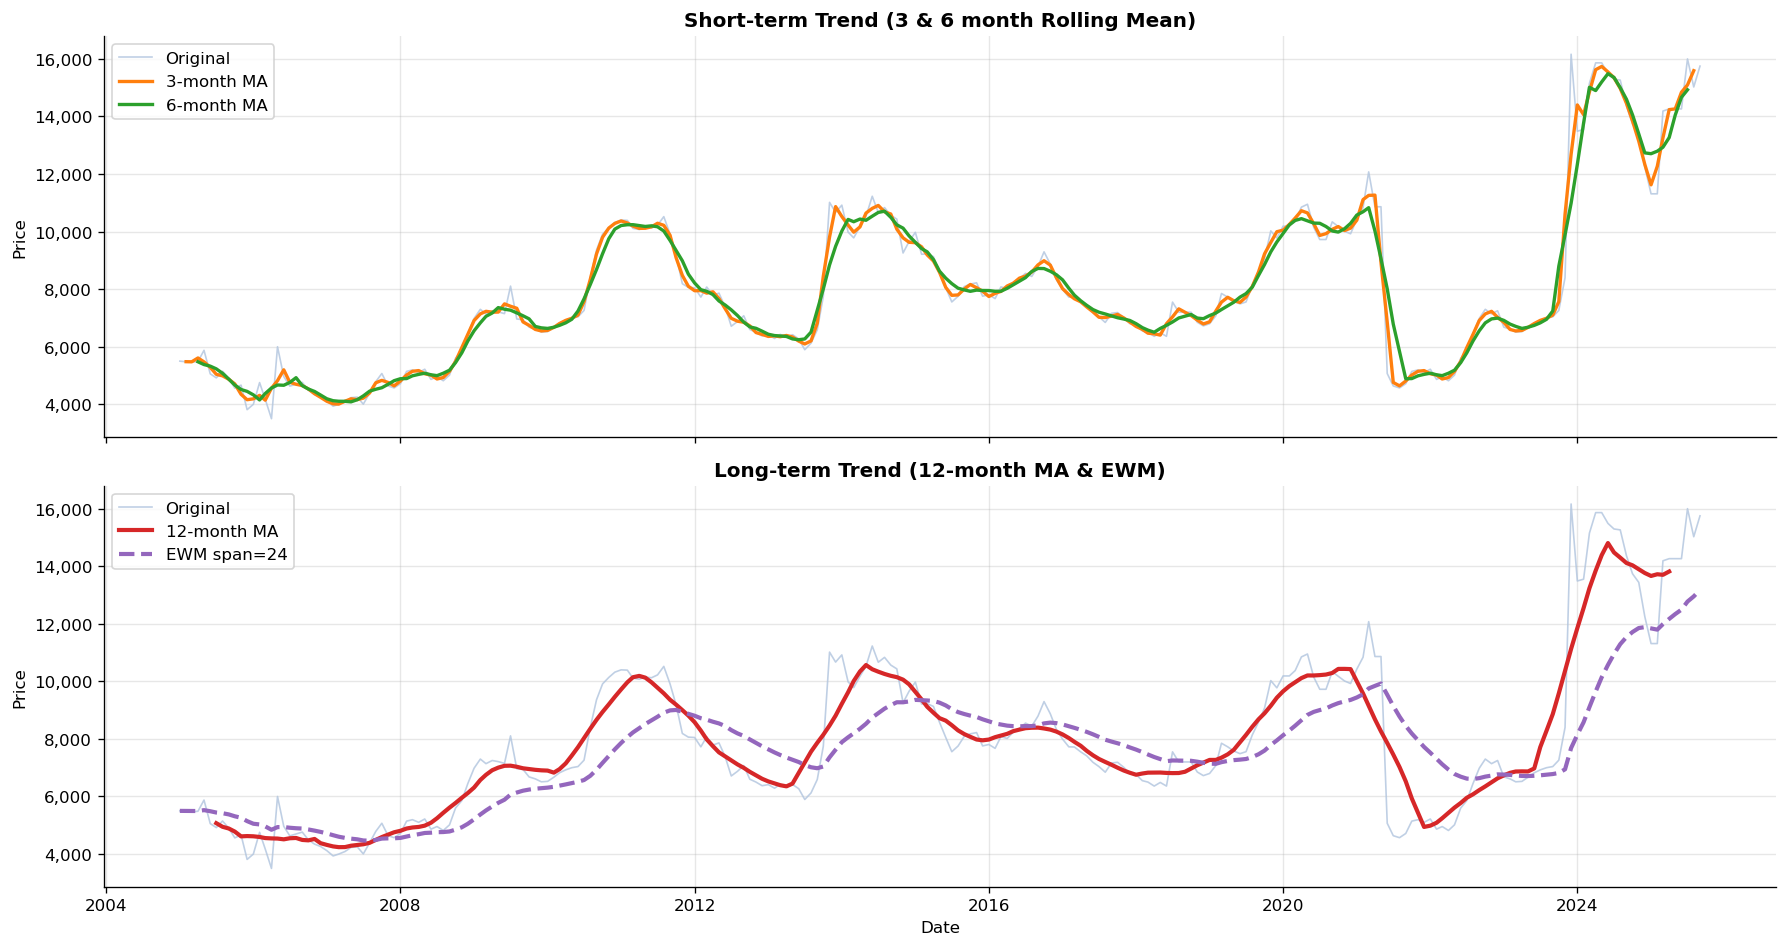

In [41]:
df['roll_3']  = df['avg_monthly_price'].rolling(window=3,  center=True).mean()
df['roll_6']  = df['avg_monthly_price'].rolling(window=6,  center=True).mean()
df['roll_12'] = df['avg_monthly_price'].rolling(window=12, center=True).mean()
df['ewm_24']  = df['avg_monthly_price'].ewm(span=24, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(df['date'], df['avg_monthly_price'], color='lightsteelblue', lw=1, alpha=0.8, label='Original')
axes[0].plot(df['date'], df['roll_3'], color=PALETTE[1], lw=2, label='3-month MA')
axes[0].plot(df['date'], df['roll_6'], color=PALETTE[2], lw=2, label='6-month MA')
axes[0].set_title('Short-term Trend (3 & 6 month Rolling Mean)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price'); axes[0].yaxis.set_major_formatter(FMT); axes[0].legend()

axes[1].plot(df['date'], df['avg_monthly_price'], color='lightsteelblue', lw=1, alpha=0.8, label='Original')
axes[1].plot(df['date'], df['roll_12'], color=PALETTE[3], lw=2.5, label='12-month MA')
axes[1].plot(df['date'], df['ewm_24'],  color=PALETTE[4], lw=2.5, ls='--', label='EWM span=24')
axes[1].set_title('Long-term Trend (12-month MA & EWM)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Price'); axes[1].yaxis.set_major_formatter(FMT); axes[1].legend()
plt.tight_layout(); plt.show()

---
Fitting OLS on raw monthly data would be distorted by seasonal cycles — the slope would partially reflect seasonal noise, not the real long-run direction. Aggregating to yearly averages first removes that noise. The regression is fit on `x - x.mean()` (centred x) to avoid numerical issues with large year integers and to make the intercept interpretable as the price at the midpoint of the series.

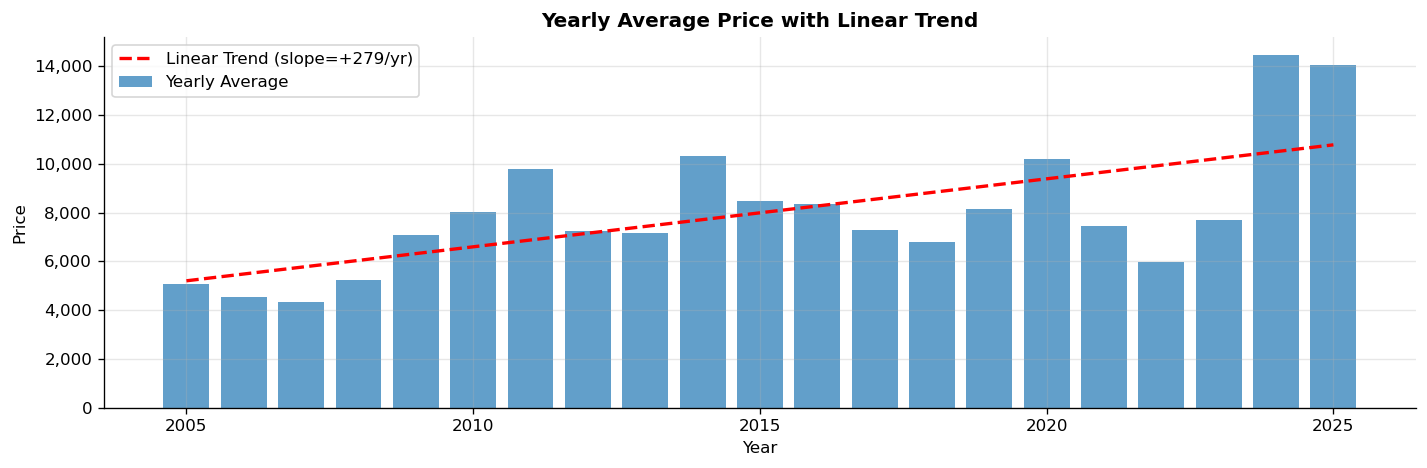

Long-term trend: +279/yr -> Prices are RISING
Lowest  year avg : 2007 (4,340)
Highest year avg : 2024 (14,479)


In [43]:
yearly_avg = df.groupby('year')['avg_monthly_price'].mean()
x = yearly_avg.index.values
y = yearly_avg.values
slope, intercept = np.polyfit(x - x.mean(), y, 1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, y, color=PALETTE[0], alpha=0.7, label='Yearly Average')
ax.plot(x, slope*(x-x.mean())+intercept, color='red', lw=2, ls='--',
        label=f'Linear Trend (slope={slope:+,.0f}/yr)')
ax.set_title('Yearly Average Price with Linear Trend', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Price'); ax.yaxis.set_major_formatter(FMT); ax.legend()
plt.tight_layout(); plt.show()

direction = 'RISING' if slope > 0 else 'FALLING'
print(f'Long-term trend: {slope:+,.0f}/yr -> Prices are {direction}')
print(f'Lowest  year avg : {yearly_avg.idxmin()} ({yearly_avg.min():,.0f})')
print(f'Highest year avg : {yearly_avg.idxmax()} ({yearly_avg.max():,.0f})')

**Observations:**
- The linear trend slope is positive — prices are rising over the long run.
- There's a visible acceleration in recent years that the linear fit undersells. The trend is not constant — it steepened post-2020.

---
## 8. Volatility Analysis

Three separate views on volatility because each catches something different:

- **MoM % change:** Proportional move, works across different price levels. Green/red bars make the direction of each month instantly readable.
- **Rolling std (3 & 6 month):** Local dispersion. Spikes here identify specific turbulent *periods* rather than individual months.
- **|Absolute diff|:** Raw ₹ magnitude. Relevant when the actual cash impact of a price swing matters, independent of percentage.

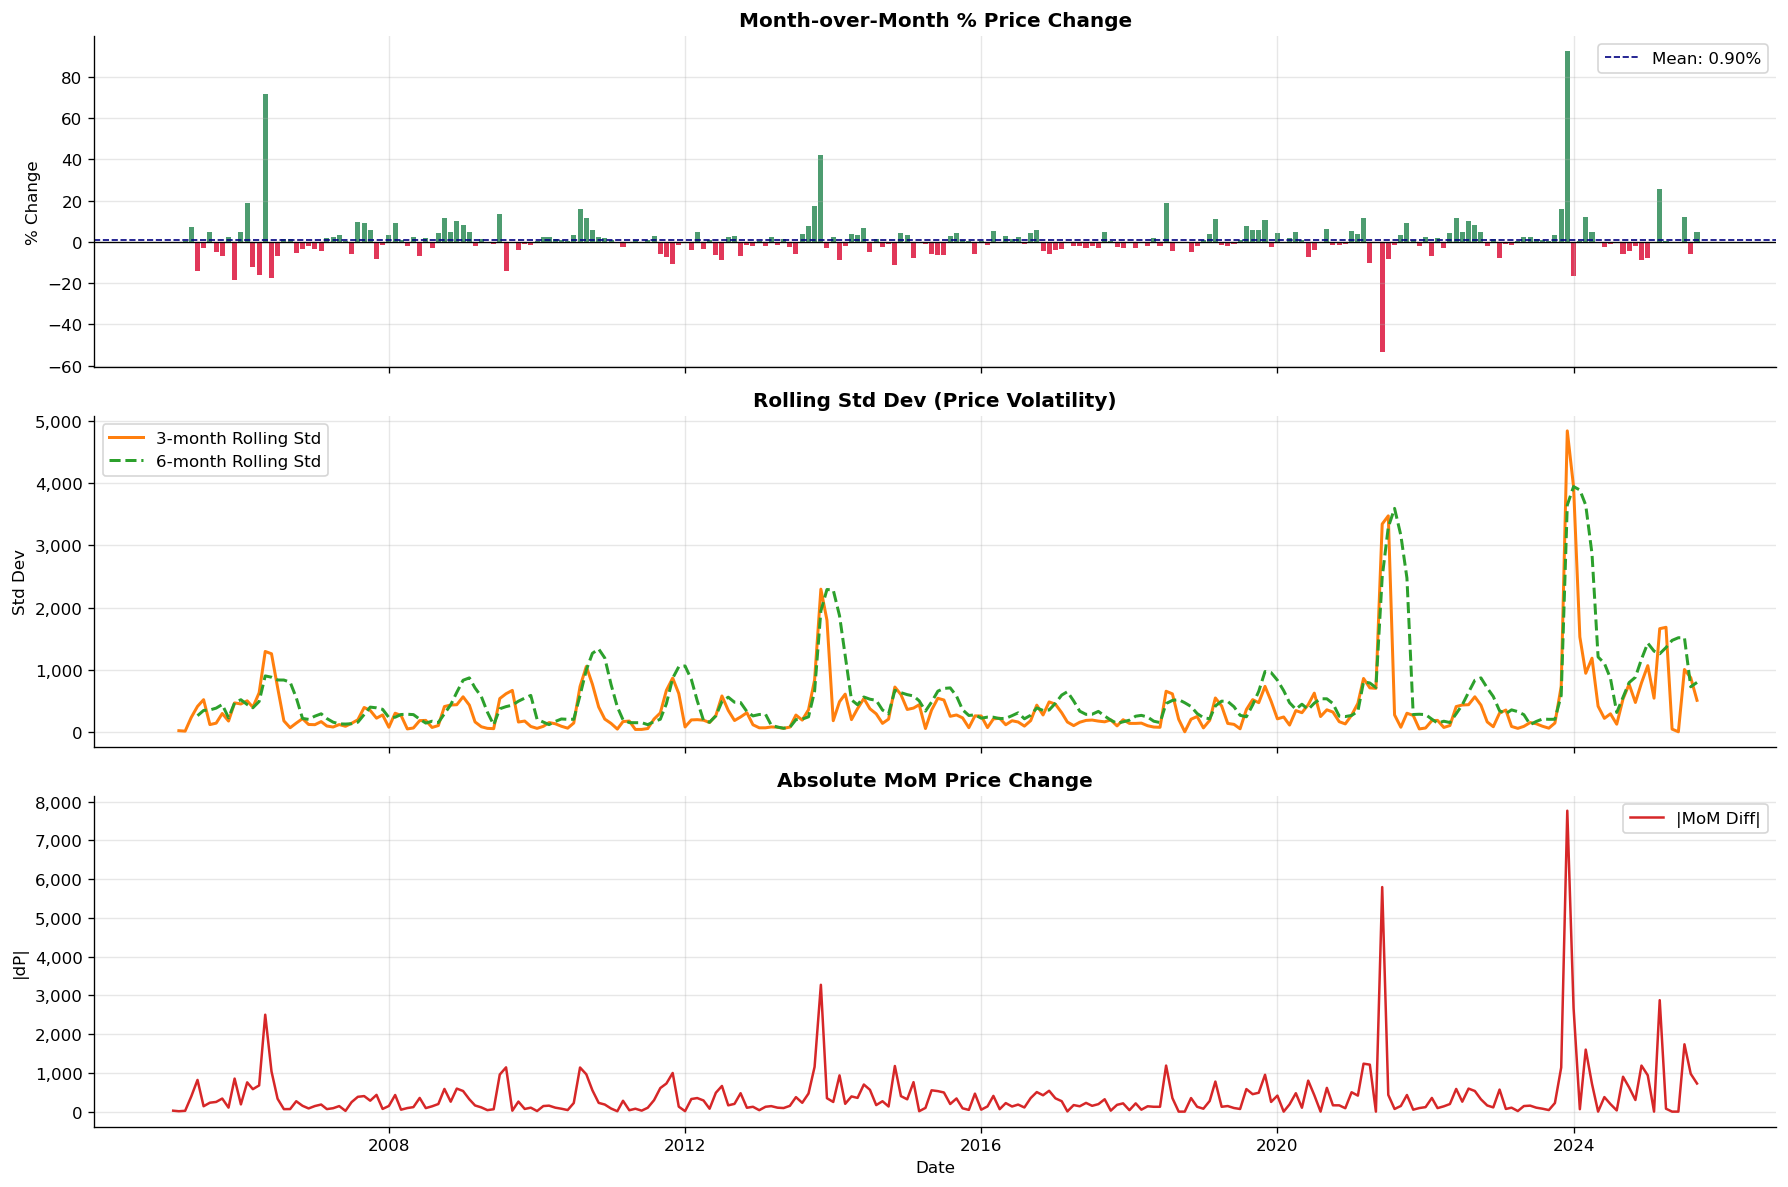

In [45]:
df['price_diff']    = df['avg_monthly_price'].diff()
df['pct_change']    = df['avg_monthly_price'].pct_change() * 100
df['rolling_std3']  = df['avg_monthly_price'].rolling(3).std()
df['rolling_std6']  = df['avg_monthly_price'].rolling(6).std()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

bar_colors = ['crimson' if x < 0 else 'seagreen' for x in df['pct_change'].fillna(0)]
axes[0].bar(df['date'], df['pct_change'], color=bar_colors, width=25, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(df['pct_change'].mean(), color='navy', ls='--', lw=1,
                label=f'Mean: {df["pct_change"].mean():.2f}%')
axes[0].set_title('Month-over-Month % Price Change', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Change'); axes[0].legend()

axes[1].plot(df['date'], df['rolling_std3'], color=PALETTE[1], lw=1.8, label='3-month Rolling Std')
axes[1].plot(df['date'], df['rolling_std6'], color=PALETTE[2], lw=1.8, ls='--', label='6-month Rolling Std')
axes[1].set_title('Rolling Std Dev (Price Volatility)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std Dev'); axes[1].yaxis.set_major_formatter(FMT); axes[1].legend()

axes[2].plot(df['date'], df['price_diff'].abs(), color=PALETTE[3], lw=1.5, label='|MoM Diff|')
axes[2].set_title('Absolute MoM Price Change', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date'); axes[2].set_ylabel('|dP|'); axes[2].yaxis.set_major_formatter(FMT); axes[2].legend()
plt.tight_layout(); plt.show()

**Observations:**
- Month-over-month changes are mostly small and symmetric — the series doesn't jump around randomly every month.
- The rolling std chart clearly shows two distinct turbulence spikes, both in the recent period. These match the outlier cluster found in Section 6.
- Absolute price changes are also disproportionately large in recent years, which confirms these aren't just percentage illusions.

---
The rolling std chart is good for spotting when turbulence happened, but it's hard to compare years at a glance. This bar chart collapses to one std per year and uses the Reds colormap (darker = more volatile) so the most turbulent years stand out immediately.

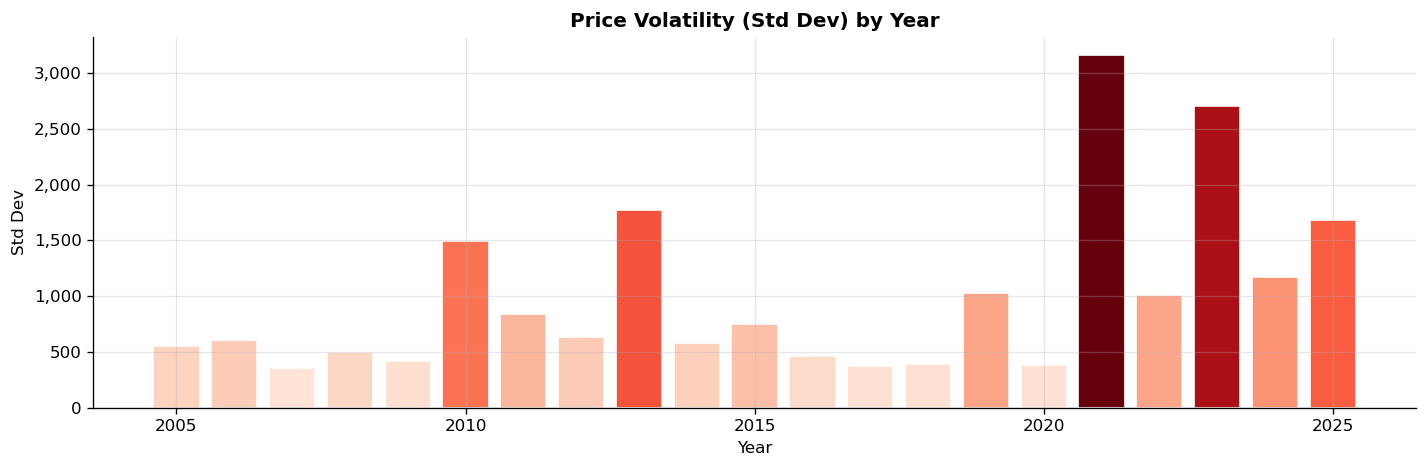

Most volatile year : 2021 (Std = 3,166)
Least volatile year: 2007 (Std = 357)


In [47]:
yearly_vol = df.groupby('year')['avg_monthly_price'].std().round(0).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly_vol.index, yearly_vol.values,
       color=plt.cm.Reds(yearly_vol.values / yearly_vol.max()), edgecolor='white')
ax.set_title('Price Volatility (Std Dev) by Year', fontsize=12, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Std Dev'); ax.yaxis.set_major_formatter(FMT)
plt.tight_layout(); plt.show()
print(f'Most volatile year : {yearly_vol.idxmax()} (Std = {yearly_vol.max():,})')
print(f'Least volatile year: {yearly_vol.idxmin()} (Std = {yearly_vol.min():,})')

**Observations:**
- Earlier years are light pink — relatively calm price movement.
- The bars darken progressively, with the most recent years showing the deepest red. Volatility has structurally increased, not just spiked once.

---
## 9. Decomposition (Trend + Seasonality + Residual)

Decomposition separates the three structural layers of the series:

1. **Trend:** The long-run direction after removing cyclical and seasonal effects.
2. **Seasonal:** The repeating annual pattern (period=12 since we have monthly data).
3. **Residual:** What remains after both are removed — should be close to white noise if the model is appropriate.

`extrapolate_trend='freq'` fills the NaN edges that `seasonal_decompose` normally leaves at the start and end of the trend component — a common gotcha that produces empty regions at the edges of the trend chart.

Starting with **additive** decomposition because it assumes seasonal swings are roughly constant in absolute magnitude across the series.

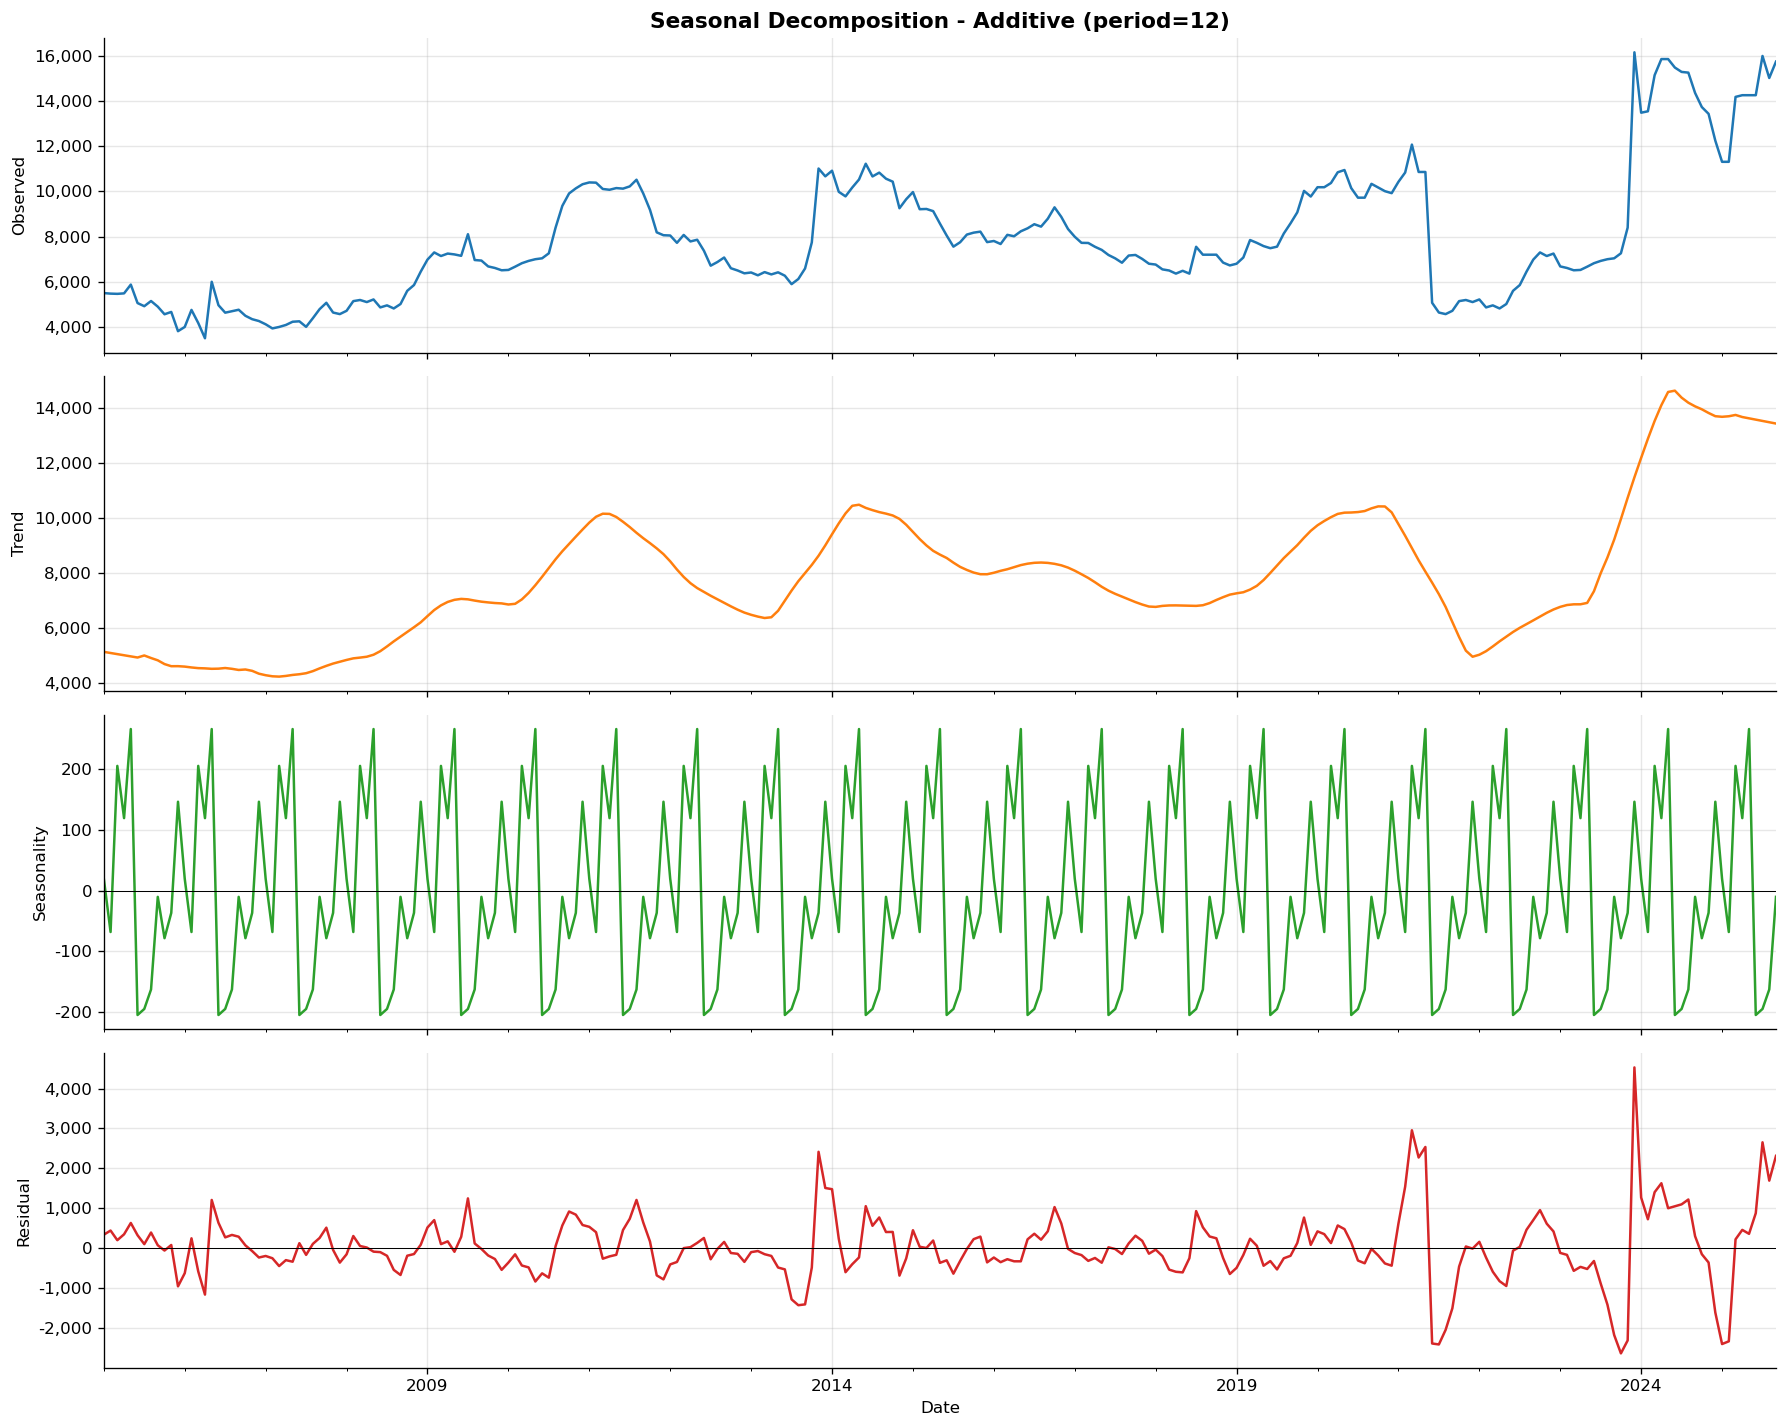

In [49]:
ts = df.set_index('date')['avg_monthly_price']
decomp_add = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
components = [decomp_add.observed, decomp_add.trend, decomp_add.seasonal, decomp_add.resid]
titles = ['Observed', 'Trend', 'Seasonality', 'Residual']
colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]
for ax, comp, title, c in zip(axes, components, titles, colors):
    comp.plot(ax=ax, color=c, lw=1.5)
    ax.set_ylabel(title)
    ax.yaxis.set_major_formatter(FMT)
    if title in ['Seasonality','Residual']:
        ax.axhline(0, color='black', lw=0.6)
axes[0].set_title('Seasonal Decomposition - Additive (period=12)', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Date')
plt.tight_layout(); plt.show()

---
Agricultural prices often show *proportional* seasonality — the seasonal swing might be 10–15% of the current price level, meaning it grows as prices grow. In that case the **multiplicative model** (Observed = Trend × Seasonal × Residual) is more appropriate.

Running both and comparing the residual components tells me which fit is better — a cleaner, more random-looking residual means the model captured the seasonal structure well.

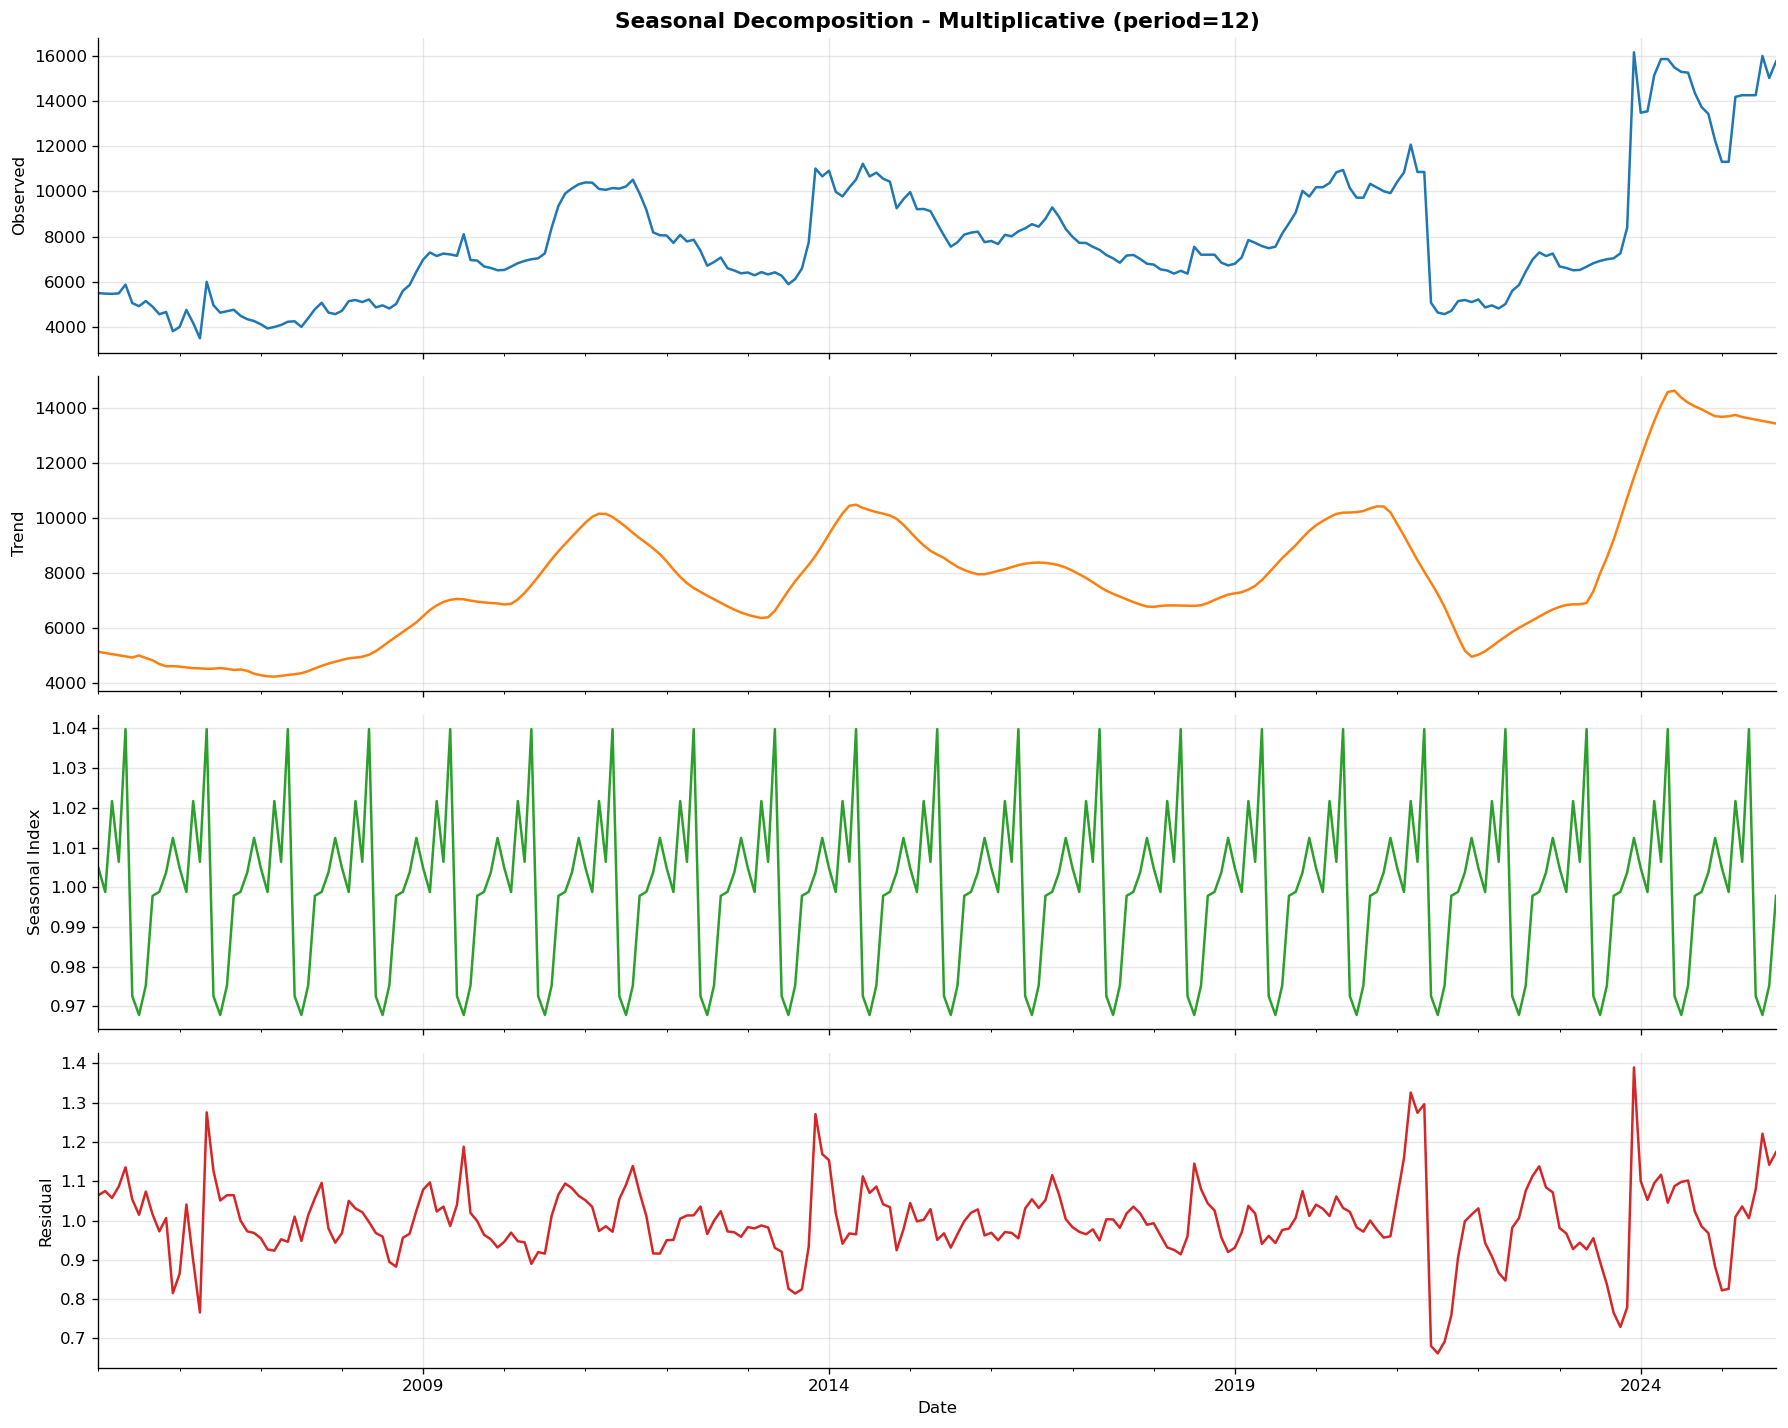

In [51]:
decomp_mul = seasonal_decompose(ts, model='multiplicative', period=12, extrapolate_trend='freq')
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
for ax, comp, title, c in zip(axes,
    [decomp_mul.observed, decomp_mul.trend, decomp_mul.seasonal, decomp_mul.resid],
    ['Observed','Trend','Seasonal Index','Residual'],
    [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]]):
    comp.plot(ax=ax, color=c, lw=1.5)
    ax.set_ylabel(title)
axes[0].set_title('Seasonal Decomposition - Multiplicative (period=12)', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Date')
plt.tight_layout(); plt.show()

**Observations:**
- The seasonal component is highly consistent in shape year over year, confirming a stable 12-month cycle.
- The trend component shows the clear upward trajectory with the post-2020 acceleration.
- The multiplicative residuals look slightly cleaner than the additive ones, which makes sense — the seasonal swings do appear to scale with price level over the long run.

---
The decomposition chart shows how the seasonal index varies month-by-month across the entire series. This next chart averages the seasonal index for each calendar month across all years, giving a single "typical" factor per month:

- **Index > 1.0 (green):** That month structurally trades above the trend — high-demand or supply-constrained period.
- **Index < 1.0 (red):** That month is typically below trend — post-harvest surplus or low-demand season.

These indices are directly actionable for procurement timing.

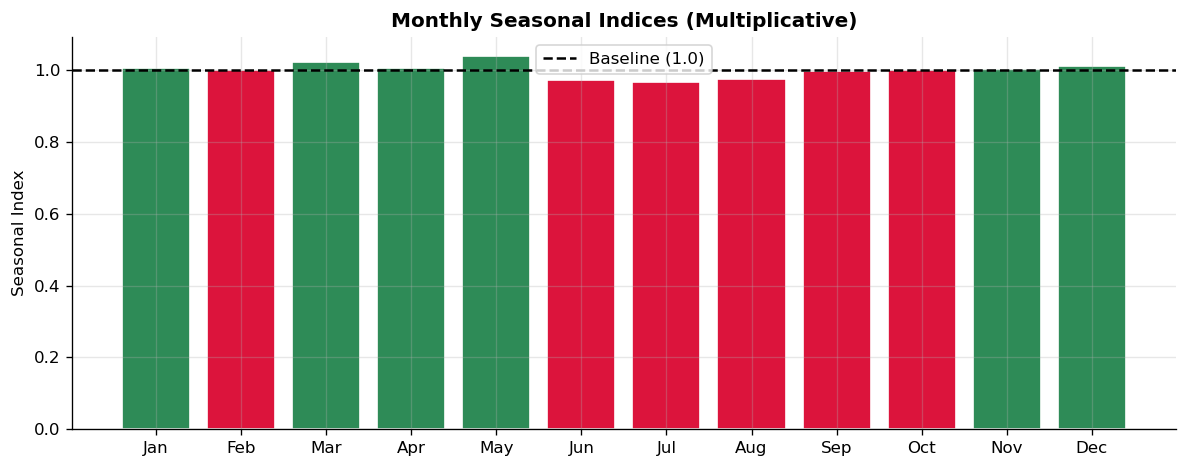

Seasonal Index (>1=high, <1=low):
  Jan : 1.0048  [HIGH]
  Feb : 0.9988  [LOW ]
  Mar : 1.0217  [HIGH]
  Apr : 1.0064  [HIGH]
  May : 1.0398  [HIGH]
  Jun : 0.9726  [LOW ]
  Jul : 0.9678  [LOW ]
  Aug : 0.9752  [LOW ]
  Sep : 0.9978  [LOW ]
  Oct : 0.9988  [LOW ]
  Nov : 1.0037  [HIGH]
  Dec : 1.0124  [HIGH]


In [53]:
seasonal_idx = decomp_mul.seasonal
tmp = pd.DataFrame({'month': ts.index.month, 'si': seasonal_idx.values})
seasonal_monthly = tmp.groupby('month')['si'].mean()
seasonal_monthly.index = MONTH_LABELS

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['crimson' if v < 1 else 'seagreen' for v in seasonal_monthly.values]
ax.bar(seasonal_monthly.index, seasonal_monthly.values, color=bar_colors, edgecolor='white')
ax.axhline(1.0, color='black', lw=1.5, ls='--', label='Baseline (1.0)')
ax.set_title('Monthly Seasonal Indices (Multiplicative)', fontsize=12, fontweight='bold')
ax.set_ylabel('Seasonal Index'); ax.legend()
plt.tight_layout(); plt.show()

print('Seasonal Index (>1=high, <1=low):')
for m, v in seasonal_monthly.items():
    tag = 'HIGH' if v > 1 else 'LOW '
    print(f'  {m:>3} : {v:.4f}  [{tag}]')

---
## 10. Model Selection

I evaluated several model families against the specific characteristics of this dataset — long history (249 months), clear seasonality, non-stationarity, and a recent structural break.

**Model Comparison**

| Model | Handles Seasonality | Custom Features | Captures Recent Trends | Recency Weighting | Complexity |
|---|---|---|---|---|---|
| ARIMA | ❌ | ❌ | ⚠️ | ❌ | Low |
| SARIMA | ✅ | ❌ | ⚠️ | ❌ | Medium |
| Prophet | ✅ | ⚠️ | ⚠️ | ❌ | Low |
| LSTM | ✅ | ❌ | ✅ | ⚠️ | High |
| Random Forest | ❌ | ✅ | ✅ | ⚠️ | Medium |
| XGBoost | ❌ (manual) | ✅ | ✅ | ✅ | Medium |
| **Hybrid SARIMA + GBM/XGB** | ✅ | ✅ | ✅ | ✅ | High |

The key constraint is the recent structural break — pure SARIMA will underfit the post-2020 regime because it weights all history equally. The hybrid approach uses SARIMA to model the seasonal and trend structure, then trains a gradient boosting model on the *residuals* to capture whatever pattern SARIMA missed. This is a well-established technique for handling non-linearities that ARIMA-family models can't represent.

**Decision: SARIMA + XGBoost and SARIMA + GBM (both trained and compared)**

Both hybrid variants are trained so I can compare which boosting approach does a better job on the residuals. The final 12-month forecast uses whichever performs better on the test split.

---
## 11. Feature Engineering & Transformations

Several transforms and features are needed before the boosting models can work well on the residuals:

**Log transform (`np.log1p`):** Stabilises variance and compresses the right tail introduced by the post-2020 price spikes. Predictions are back-transformed with `np.expm1` at the end.

**Lag features (1, 2, 3, 12):** Give the model direct access to recent price history. Lag 12 is especially important — it's the same month last year, which is the single strongest predictor for seasonal series.

**Rolling mean and std (3-month):** Encode short-term momentum and local volatility into each row, so the model doesn't have to infer them from individual lags alone.

**Seasonal encoding (sin/cos of month):** Converts the month integer into circular features — ensures the model understands that December and January are adjacent, not 11 months apart.

**Recency weighting:** Sample weights that increase exponentially for more recent observations. This makes the boosting models prioritise fitting the post-2020 regime without discarding earlier data entirely.

Note: the `avg_monthly_price` column is renamed to `price` after the log transform, and all EDA columns (rolling means, outlier flags etc.) are dropped to keep the feature set clean.

In [55]:
df.head(1)

,date,avg_monthly_price,year,month,month_name,quarter,season,iqr_outlier,zscore,zscore_outlier,roll_3,roll_6,roll_12,ewm_24,price_diff,pct_change,rolling_std3,rolling_std6
0,2005-01-01,5500,2005,1,Jan,1,Winter,False,0.864089,False,NaN,NaN,NaN,5500.0,NaN,NaN,NaN,NaN


In [57]:
# Set index
df.set_index('date', inplace=True)

# Ensure monthly frequency
df = df.asfreq('MS')

# Rename target column
#df['price'] = df['price_diff']
df['price']=df['avg_monthly_price']

# =========================
# 2. LOG TRANSFORM
# =========================

df['price'] = np.log1p(df['price'])

# =========================
# 3. LAG FEATURES
# =========================

df['lag_1'] = df['price'].shift(1)
df['lag_2'] = df['price'].shift(2)
df['lag_3'] = df['price'].shift(3)
df['lag_12'] = df['price'].shift(12)

# =========================
# 4. ROLLING FEATURES
# =========================

df['rolling_mean_3'] = df['price'].shift(1).rolling(3).mean()
df['rolling_std_3'] = df['price'].shift(1).rolling(3).std()

# =========================
# 5. TREND FEATURES
# =========================

df['diff_1'] = df['price'].diff(1)

# =========================
# 6. SEASONAL FEATURES
# =========================

df['month'] = df.index.month

df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# =========================
# 7. YEARLY CONTEXT
# =========================

df['avg_price_last_year'] = df['price'].shift(1).rolling(12).mean()

# =========================
# 8. RECENCY WEIGHT
# =========================

current_year = df.index.year.max()
df['weight'] = np.exp(-0.3 * (current_year - df.index.year))

# =========================
# 9. DROP UNUSED COLUMNS
# =========================

drop_cols = [
    'avg_monthly_price', 'month_name', 'quarter', 'season',
    'iqr_outlier', 'zscore', 'zscore_outlier',
    'roll_3', 'roll_6', 'roll_12', 'ewm_24',
    'price_diff', 'pct_change',
    'rolling_std3', 'rolling_std6'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [59]:
df.head()

,year,month,price,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_std_3,diff_1,sin_month,cos_month,avg_price_last_year,weight
date,,,,,,,,,,,,,,
2005-01-01,2005,1,8.612685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,NaN,0.002479
2005-02-01,2005,2,8.608313,8.612685,NaN,NaN,NaN,NaN,NaN,-0.004372,0.866025,5.000000e-01,NaN,0.002479
2005-03-01,2005,3,8.606485,8.608313,8.612685,NaN,NaN,NaN,NaN,-0.001827,1.000000,6.123234e-17,NaN,0.002479
2005-04-01,2005,4,8.610319,8.606485,8.608313,8.612685,NaN,8.609161,0.003186,0.003834,0.866025,-5.000000e-01,NaN,0.002479
2005-05-01,2005,5,8.678802,8.610319,8.606485,8.608313,NaN,8.608372,0.001918,0.068483,0.500000,-8.660254e-01,NaN,0.002479


---
## 12. SARIMA Model Training and Evaluation

The SARIMA search is done with a manual grid rather than `auto_arima` — mainly for transparency and to keep the search space tight based on what the ACF/PACF already suggested.

The two arrays `a` and `A` define the non-seasonal (p,d,q) and seasonal (P,D,Q) order combinations to try. Each row is one combination. The nested loop fits every combination of non-seasonal × seasonal orders and keeps whichever produces the lowest AIC. Models that fail to converge are skipped silently.

In [65]:
from itertools import product

# Define ranges
p = range(0, 4)   # 0–3
d = range(0, 3)   # 0–2
q = range(0, 4)   # 0–3

P = range(0, 3)   # 0–2
D = range(0, 2)   # 0–1
Q = range(0, 3)   # 0–2

# Generate combinations
a = np.array(list(product(p, d, q)))   # (p,d,q)
A = np.array(list(product(P, D, Q)))   # (P,D,Q)

# Check
print("a shape:", a.shape)
print("A shape:", A.shape)
print(a[:5])  # first few combinations
print(A[:5])

a shape: (48, 3)
A shape: (18, 3)
[[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 0 3]
 [0 1 0]]
[[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 1 0]
 [0 1 1]]


In [63]:
# Initialize trackers
best_aic = float('inf')
best_order = None
best_seasonal_order = None
best_model = None

# Loop over all combinations
for i in range(len(a)):
    for j in range(len(A)):
        p, d, q = a[i]
        P, D, Q = A[j]

        try:
            model = SARIMAX(
                df['price'],
                order=(p, d, q),
                seasonal_order=(P, D, Q, 12),  # monthly seasonality
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            # Check if this model is better
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, d, q)
                best_seasonal_order = (P, D, Q, 12)
                best_model = model

        except Exception as e:
            print(f"Failed for order {(p,d,q)} seasonal {(P,D,Q,12)}: {e}")
            continue

# Assign best model
best_sarimax = best_model

# Print results
print("Best SARIMAX model:")
print(f"Order (p,d,q): {best_order}")
print(f"Seasonal order (P,D,Q,s): {best_seasonal_order}")
print(f"AIC: {best_aic}")



C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\gopal\anaconda3\envs\ML\lib\site-packages\statsmodels\base\

Best SARIMAX model:
Order (p,d,q): (np.int64(2), np.int64(1), np.int64(3))
Seasonal order (P,D,Q,s): (np.int64(0), np.int64(0), np.int64(1), 12)
AIC: -454.9933615760975


NameError: name 'pickle' is not defined

In [71]:
# =========================
# ✅ Save the model (recommended way)
# =========================
best_sarimax.save("best_sarimax_model.pkl")

# =========================
# ✅ Optional: Save using pickle (backup)
# =========================
with open("best_sarimax_pickle.pkl", "wb") as f:
    pickle.dump(best_sarimax, f)

# =========================
# ✅ Save metadata
# =========================
model_info = {
    "order": best_order,
    "seasonal_order": best_seasonal_order,
    "aic": best_aic
}

with open("sarimax_metadata.pkl", "wb") as f:
    pickle.dump(model_info, f)

In [73]:
# 1. Get residuals to feed to XGBoost / LightGBM
residuals = best_sarimax.resid.dropna()

# 2. Prepare features for boosting (e.g., lag features)
df_ml = pd.DataFrame({
    'residual': residuals
})
for lag in range(1, 13):
    df_ml[f'lag_{lag}'] = df_ml['residual'].shift(lag)

df_ml['rolling_mean_3'] = df_ml['residual'].rolling(3).mean()
df_ml['rolling_std_3'] = df_ml['residual'].rolling(3).std()

df_ml = df_ml.dropna()

<Axes: title={'center': 'SARIMA Residuals'}, xlabel='date'>

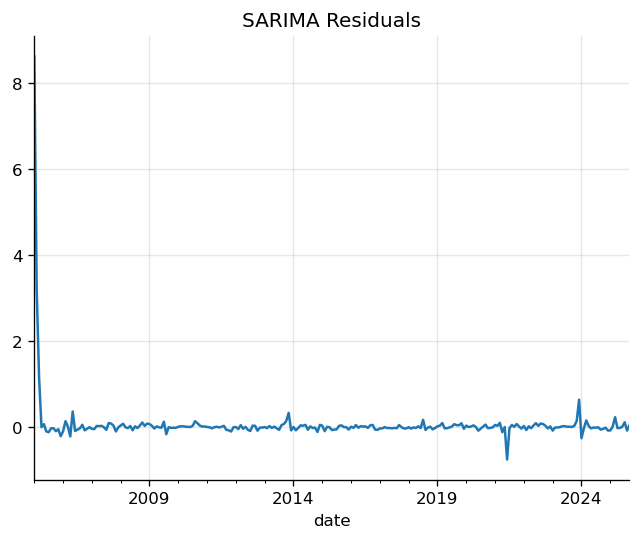

In [130]:
residuals.plot(title="SARIMA Residuals")

The residual plot should look like noise — no obvious trend, no seasonal humps, and the values centred around zero. If there's still structure visible here, it means SARIMA didn't fully capture the series and the boosting model will need to work harder. Residuals drifting away from zero in recent periods would be a red flag.

---
## 13. GBM and XGBoost — Residual Model Training

80/20 train/test split on the residual series. Since this is a time series, the split is sequential — the last 20% of residuals form the test set, not a random sample. Random splitting would leak future information into training and give artificially good metrics.

The `recency_weight` array logarithmically scales across the training set. Combined with the `error_weight` (proportional to the magnitude of each residual), the final `weights` vector forces the model to focus on recent, large errors — exactly where we want it to be accurate for near-term forecasting.

In [77]:
train_size = int(len(df_ml) * 0.8)

train = df_ml[:train_size]
test = df_ml[train_size:]

X_train = train.drop('residual', axis=1)
y_train = train['residual']

X_test = test.drop('residual', axis=1)
y_test = test['residual']

indices = np.arange(1, len(y_train)+1)
recency_weight = np.log(indices + 1)
error_weight = np.abs(y_train)

weights = recency_weight * (1 + error_weight)

Grid search over learning rates (0.01 to 0.09 in steps of 0.01) and max depths (1 to 9). 81 combinations × 2 models = 162 model fits. The results are collected into a dataframe and sorted by RMSE so the best hyperparameters are at the top.

Both XGBoost and GBM are searched together so we can compare them on equal footing before committing to one.

In [79]:
# Evaluation function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# Track best model
best_rmse = float("inf")
best_residual_model = None
best_model_name = None
best_params = {}

# Loop
for i in range(1, 10):
    for j in range(1, 10):
        lr = 0.01 * i

        # XGBoost
        xgb_model = XGBRegressor(
            n_estimators=500,
            learning_rate=lr,
            max_depth=j
        )
        xgb_model.fit(X_train, y_train, sample_weight=weights)
        xgb_pred = xgb_model.predict(X_test)
        xgb_rmse = evaluate_model(y_test, xgb_pred)

        if xgb_rmse < best_rmse:
            best_rmse = xgb_rmse
            best_residual_model = xgb_model
            best_model_name = "XGBoost"
            best_params = {"learning_rate": lr, "max_depth": j}

        # Gradient Boosting
        gbm_model = GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=lr,
            max_depth=j,
            random_state=42
        )
        gbm_model.fit(X_train, y_train, sample_weight=weights)
        gbm_pred = gbm_model.predict(X_test)
        gbm_rmse = evaluate_model(y_test, gbm_pred)

        if gbm_rmse < best_rmse:
            best_rmse = gbm_rmse
            best_residual_model = gbm_model
            best_model_name = "Gradient Boosting"
            best_params = {"learning_rate": lr, "max_depth": j}


# ✅ Print best model info
print("\n🏆 Best Residual Model:")
print("Model:", best_model_name)
print("Best RMSE:", round(best_rmse, 3))
print("Best Parameters:", best_params)


# =========================
# ✅ Save best model
# =========================
with open("best_residual_model.pkl", "wb") as f:
    pickle.dump(best_residual_model, f)


# =========================
# ✅ Save metadata
# =========================
model_info = {
    "model": best_model_name,
    "rmse": best_rmse,
    "params": best_params
}

with open("best_residual_model_meta.pkl", "wb") as f:
    pickle.dump(model_info, f)


🏆 Best Residual Model:
Model: XGBoost
Best RMSE: 0.067
Best Parameters: {'learning_rate': 0.09, 'max_depth': 1}


Best parameters from the grid search: `learning_rate=0.09`, `max_depth=1`. Shallow trees (depth 2) make sense here — the residuals are relatively smooth, and deep trees would overfit to noise. Both XGBoost and GBM are retrained from scratch with these parameters for the final comparison.

---
## 14. 12-Month Price Forecast

The forecast is built in two stages for each of the 12 future months:

1. **SARIMA forecast:** `best_sarimax.forecast(steps=12)` gives the trend + seasonal component for the next 12 months in log-price space.

2. **Residual correction (iterative):** For each step, I construct a feature row from the last 12 known residuals plus rolling stats, pass it to the GBM model, and get a predicted residual. That residual is added to the SARIMA forecast for that step, and then appended to the residual history so the *next* step's feature row uses the latest prediction — not a stale value.

3. **Back-transform:** The combined forecast in log-space is back-transformed with `np.expm1` to return actual price values (₹).

In [83]:
best_residual_model# 1. Forecast SARIMAX for next 12 months
sarimax_forecast = best_sarimax.forecast(steps=12)

# 2. Prepare residual history (last known residuals)
residual_series = residuals.copy()

# Store predicted residuals
predicted_residuals = []

# 3. Iteratively predict next 12 residuals
for step in range(12):
    
    # Create feature row
    feature_dict = {}
    
    # Lag features (last 12 residuals)
    for lag in range(1, 13):
        feature_dict[f'lag_{lag}'] = residual_series.iloc[-lag]
    
    # Rolling features
    feature_dict['rolling_mean_3'] = residual_series.iloc[-3:].mean()
    feature_dict['rolling_std_3'] = residual_series.iloc[-3:].std()
    
    # Convert to DataFrame
    X_next = pd.DataFrame([feature_dict])
    
    # Predict residual
    next_residual = best_residual_model.predict(X_next)[0]
    
    # Store prediction
    predicted_residuals.append(next_residual)
    
    # Append to residual series for next iteration
    residual_series = pd.concat([
        residual_series,
        pd.Series([next_residual], index=[sarimax_forecast.index[step]])
    ])

# Convert to Series
predicted_residuals = pd.Series(predicted_residuals, index=sarimax_forecast.index)

# 4. Final prediction = SARIMAX + residual correction
final_forecast_log = sarimax_forecast + predicted_residuals
final_forecast = np.expm1(final_forecast_log)
final_forecast

2025-10-01    16766.457428
2025-11-01    15262.340355
2025-12-01    16431.107798
2026-01-01    16404.360211
2026-02-01    15671.062100
2026-03-01    16073.537865
2026-04-01    16123.957031
2026-05-01    15974.463919
2026-06-01    16166.940879
2026-07-01    16000.801501
2026-08-01    16093.668084
2026-09-01    16104.246574
Freq: MS, dtype: float64

The output above shows the predicted average monthly price for each of the next 12 months. These are point estimates — for production use, it would make sense to also compute prediction intervals around each point, either via SARIMA's built-in confidence intervals or bootstrap sampling on the residual model.

### Actions a company could take to respond to predicted price changes.

**If prices are predicted to rise:**
- Buy inventory early, before the increase hits. Forward-buying at current rates reduces procurement cost.
- Lock in supplier contracts at current prices while they're still favourable.
- Gradually adjust product pricing upward to protect margins — sharp sudden increases tend to hurt customer retention more than gradual ones.
- Push substitutes or lower-cost alternatives in the product mix to manage margin pressure.

**If prices are predicted to fall:**
- Delay bulk purchasing and reduce safety stock levels — buying now means overpaying.
- Wind down existing inventory before restocking at lower prices.
- Run promotional pricing to clear current stock at acceptable margins before the new lower-cost inventory arrives.
- Update pricing models to remain competitive as input costs drop.

In practice, the response falls across five business functions:

**1. Pricing Strategy** — Adjust selling prices proactively based on forecast direction. Dynamic pricing tied to the model output avoids reactive margin compression.

**2. Procurement / Supply Chain** — Time purchases to the forecast. Negotiate forward contracts when prices are predicted to rise, spot purchases when they're predicted to fall.

**3. Inventory Management** — Align stock levels to the forecast. Building buffer stock before a predicted spike has a clear ROI; holding excess stock before a predicted drop ties up working capital.

**4. Marketing** — Run promotions during predicted high-price periods to sustain volume; hold back discounts during predicted low-price periods when demand will hold anyway.

**5. Financial Planning** — Use the forecast as a procurement budget input. Hedging instruments (futures, options) become more attractive when the model signals high confidence in a directional move.

### How to determine if the implemented actions are effective?

The core approach is to track what changed against what was predicted, and attribute the outcome to the action.

**Quantitative KPIs to monitor:**
- Procurement cost per unit vs. the pre-action baseline
- Gross margin change in the months following each action
- Inventory holding cost and stockout rate
- Revenue during promotional periods vs. comparable prior periods

**Attribution approach:**
- Compare actual procurement timing against the model's recommended timing
- Calculate the cost saving (or cost if the signal was wrong) for each forward-buying decision
- Track forecast accuracy (MAE, MAPE) over time — if it degrades, that's a signal for retraining, not necessarily that the business actions are wrong

**What to watch for:**
- If margins improved during a predicted price spike and procurement costs were lower, the actions worked
- If the model predicted a rise but prices fell, assess whether it was model error or a genuinely unpredictable shock (e.g. policy intervention, weather event)

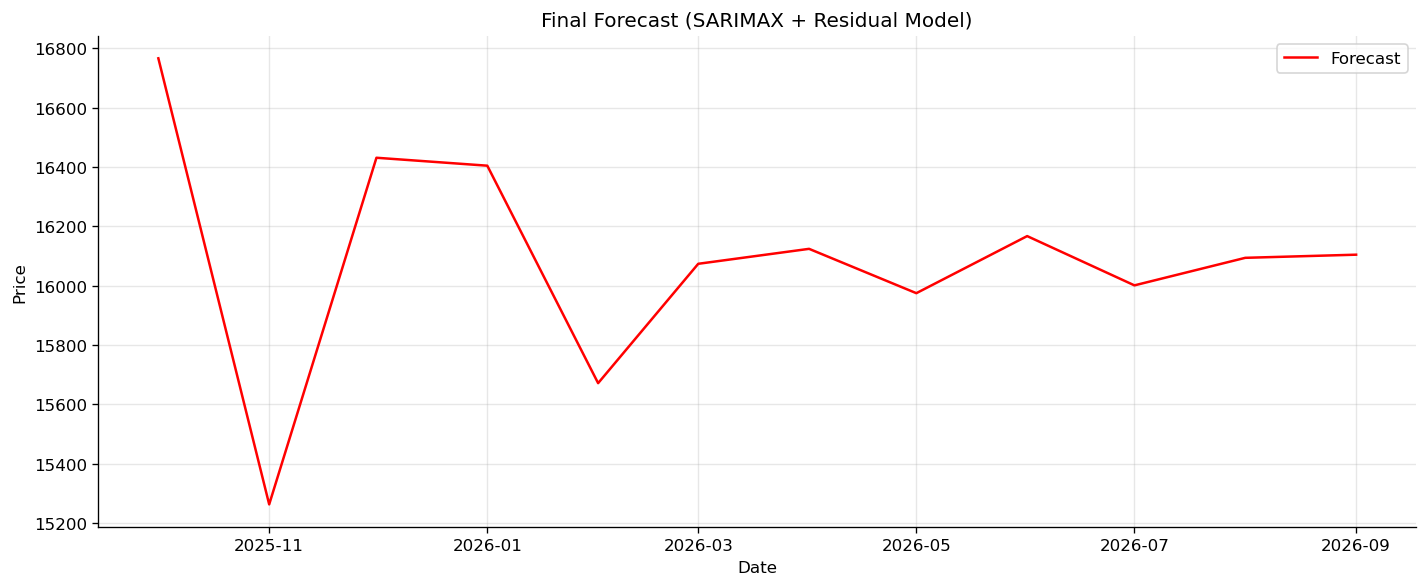

✅ Forecast saved to result.json


In [87]:
import json
import os

# =========================
# ✅ Plot forecast only
# =========================
plt.figure(figsize=(12, 5))

plt.plot(final_forecast.index, final_forecast, label="Forecast", color="red")

plt.title("Final Forecast (SARIMAX + Residual Model)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()

# Save plot
plt.savefig("final_forecast.png", dpi=300, bbox_inches='tight')

plt.show()


# =========================
# ✅ Save forecast to JSON
# =========================

forecast_dict = {
    str(date): float(value)
    for date, value in final_forecast.items()
}

file_path = "result.json"

# Load existing data if file exists
if os.path.exists(file_path):
    with open(file_path, "r") as f:
        try:
            data = json.load(f)
        except:
            data = {}
else:
    data = {}

# Update forecast
data["final_forecast"] = forecast_dict

# Save file
with open(file_path, "w") as f:
    json.dump(data, f, indent=4)

print("✅ Forecast saved to result.json")